In [2]:
# ============================================================
# Cell 1: Check the dataset folder structure
# Purpose: Understand how the MVTec AD dataset is organized 
#          inside the 'archive' folder before we start coding
# ============================================================

import os

# Path to extracted dataset folder
base_path = "archive"

# List everything inside the archive folder
print("Contents of 'archive' foler: ")
print("–" * 40)
for item in sorted(os.listdir(base_path)):
    print(f"  {item}")

Contents of 'archive' foler: 
––––––––––––––––––––––––––––––––––––––––
  .DS_Store
  bottle
  cable
  capsule
  carpet
  grid
  hazelnut
  leather
  license.txt
  metal_nut
  pill
  readme.txt
  screw
  tile
  toothbrush
  transistor
  wood
  zipper


In [3]:
# ============================================================
# Cell 2: Explore the internal structure of our 3 categories
# Purpose: See how train/test folders and defect types are 
#          organized for carpet, hazelnut, and screw
# ============================================================

# The 3 categories we're focusing on (as per our proposal)

categories = ["carpet", "hazelnut", "screw"]

for category in categories:
    cat_path = os. path.join(base_path, category)
    print(f"\n{'='*50}")
    print(f"Category: {category.upper()}")
    print(f"{'='*50}")

    for split in sorted(os.listdir(cat_path)):
        split_path = os.path.join(cat_path, split)
        if os.path.isdir(split_path):
            print(f"\n  [{split}]")
            for subfolder in sorted(os.listdir(split_path)):
                sub_path = os.path.join(split_path, subfolder)
                if os.path.isdir(sub_path):
                    # Count number of images in each subfolder
                    num_images = len([f for f in os.listdir(sub_path) 
                                      if f.endswith(('.png', '.jpg', '.jpeg'))])
                    print(f"    {subfolder}: {num_images} images")
    


Category: CARPET

  [ground_truth]
    color: 19 images
    cut: 17 images
    hole: 17 images
    metal_contamination: 17 images
    thread: 19 images

  [test]
    color: 19 images
    cut: 17 images
    good: 28 images
    hole: 17 images
    metal_contamination: 17 images
    thread: 19 images

  [train]
    good: 280 images

Category: HAZELNUT

  [ground_truth]
    crack: 18 images
    cut: 17 images
    hole: 18 images
    print: 17 images

  [test]
    crack: 18 images
    cut: 17 images
    good: 40 images
    hole: 18 images
    print: 17 images

  [train]
    good: 391 images

Category: SCREW

  [ground_truth]
    manipulated_front: 24 images
    scratch_head: 24 images
    scratch_neck: 25 images
    thread_side: 23 images
    thread_top: 23 images

  [test]
    good: 41 images
    manipulated_front: 24 images
    scratch_head: 24 images
    scratch_neck: 25 images
    thread_side: 23 images
    thread_top: 23 images

  [train]
    good: 320 images


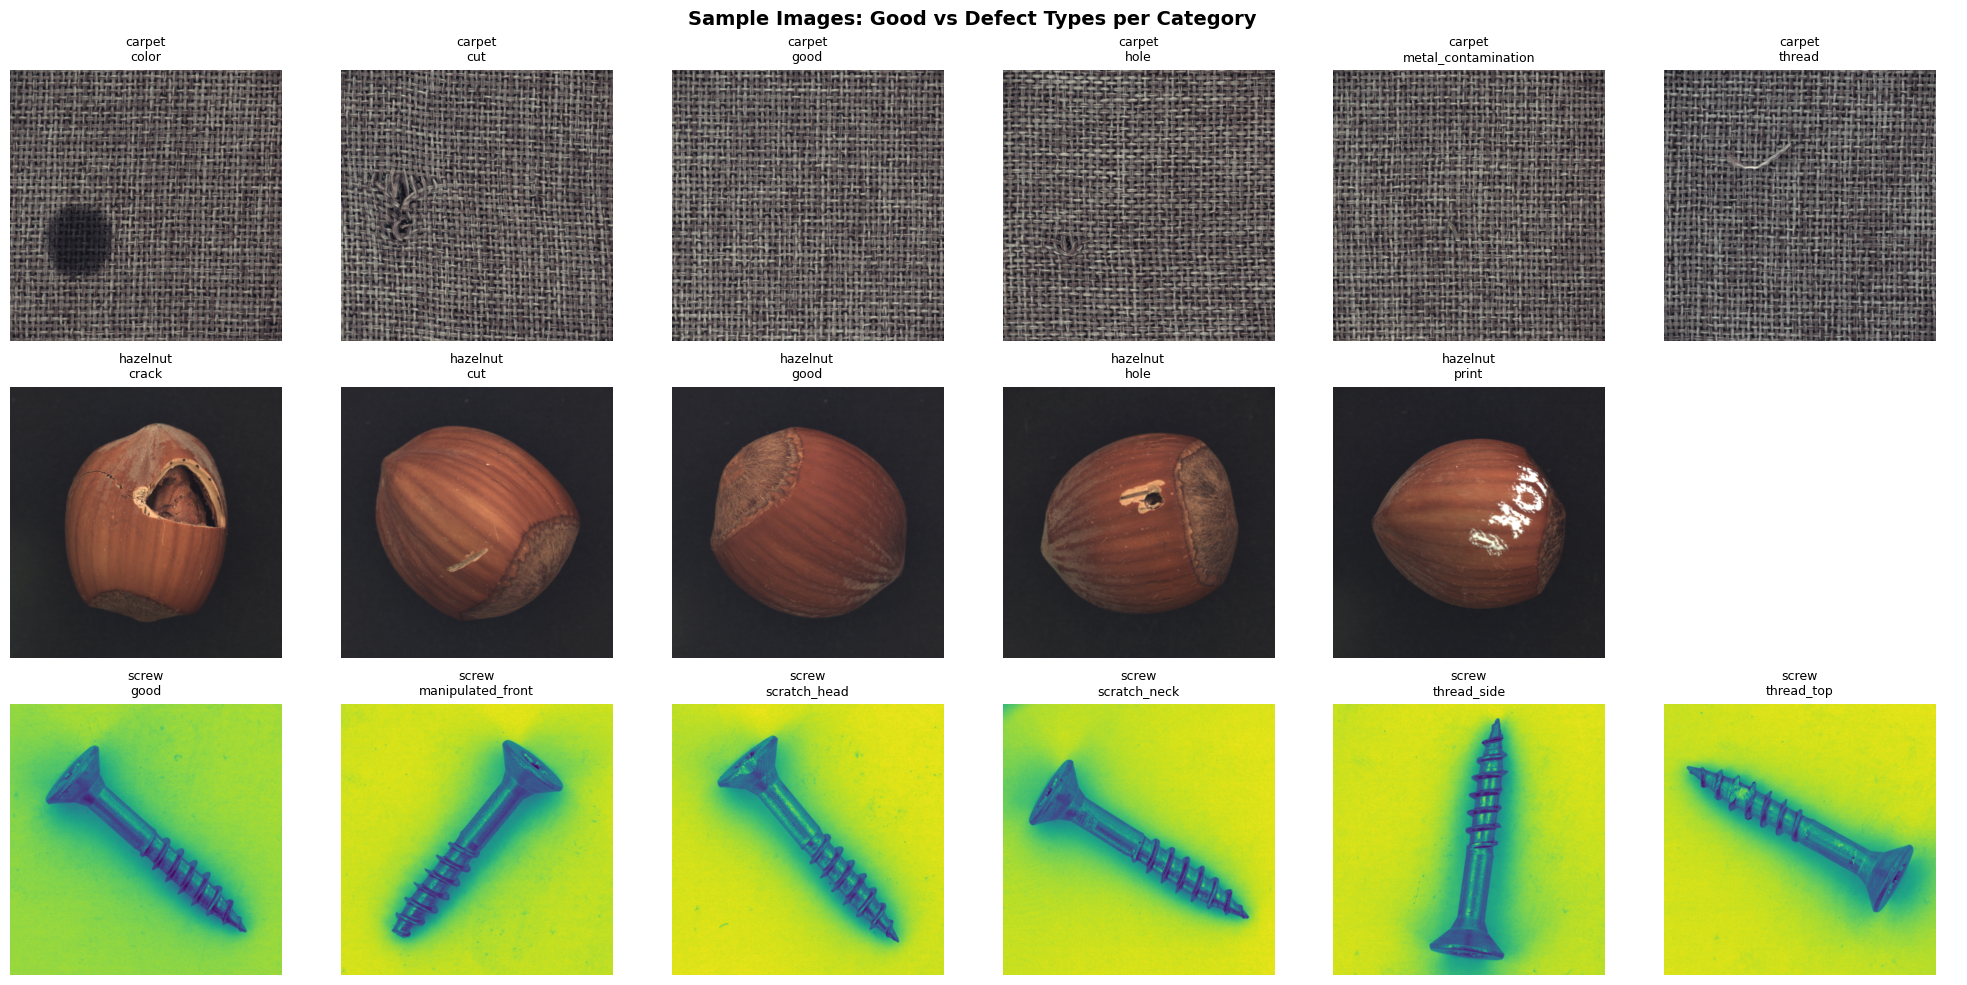

In [4]:
# ============================================================
# Cell 3: Visualize sample images from each category
# Purpose: Get a visual understanding of what "good" images 
#          look like vs different defect types. This helps us
#          understand what our model needs to learn.
# ============================================================

import matplotlib.pyplot as plt
from PIL import Image

fig, axes = plt.subplots(3, 6, figsize=(20, 10))

for row, category in enumerate(categories):
    cat_path = os.path.join(base_path, category)
    
    # Get all subfolders in the test set (good + defect types)
    test_path = os.path.join(cat_path, "test")
    subfolders = sorted(os.listdir(test_path))
    # Keep only actual directories (skip hidden files like .DS_Store)
    subfolders = [s for s in subfolders if os.path.isdir(os.path.join(test_path, s))]
    
    # Show up to 6 subfolders (good + defect types)
    for col in range(min(6, len(subfolders))):
        subfolder = subfolders[col]
        img_dir = os.path.join(test_path, subfolder)
        # Pick the first image from this subfolder
        img_name = sorted([f for f in os.listdir(img_dir) 
                           if f.endswith(('.png', '.jpg', '.jpeg'))])[0]
        img = Image.open(os.path.join(img_dir, img_name))
        
        axes[row, col].imshow(img)
        axes[row, col].set_title(f"{category}\n{subfolder}", fontsize=9)
        axes[row, col].axis("off")
    
    # Turn off any unused columns for this row
    for col in range(len(subfolders), 6):
        axes[row, col].axis("off")

plt.suptitle("Sample Images: Good vs Defect Types per Category", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [5]:
# ============================================================
# Cell 4: Check image properties (size, channels, dtype)
# Purpose: Before feature extraction, we need to know the 
#          original image dimensions and number of channels.
#          This helps us decide on resizing and preprocessing.
# ============================================================

import numpy as np

for category in categories:
    # Grab one training image from each category
    train_good_path = os.path.join(base_path, category, "train", "good")
    img_name = sorted(os.listdir(train_good_path))[0]
    img = Image.open(os.path.join(train_good_path, img_name))
    img_array = np.array(img)
    
    print(f"{category.upper()}")
    print(f"  Image size (W x H): {img.size}")
    print(f"  Array shape (H, W, C): {img_array.shape}")
    print(f"  Dtype: {img_array.dtype}")
    print(f"  Pixel range: [{img_array.min()}, {img_array.max()}]")
    print(f"  Mode: {img.mode}")
    print()

CARPET
  Image size (W x H): (1024, 1024)
  Array shape (H, W, C): (1024, 1024, 3)
  Dtype: uint8
  Pixel range: [5, 255]
  Mode: RGB

HAZELNUT
  Image size (W x H): (1024, 1024)
  Array shape (H, W, C): (1024, 1024, 3)
  Dtype: uint8
  Pixel range: [23, 218]
  Mode: RGB

SCREW
  Image size (W x H): (1024, 1024)
  Array shape (H, W, C): (1024, 1024)
  Dtype: uint8
  Pixel range: [30, 210]
  Mode: L



In [6]:
# ============================================================
# Cell 5: Build the data loading function
# Purpose: Create a function that loads all images for a given
#          category and split, handles grayscale->RGB conversion,
#          and returns image paths, labels, and defect types.
#          We're NOT loading pixel data into memory yet — just
#          organizing the file paths and labels.
# ============================================================

def get_image_paths_and_labels(base_path, category, split="test"):
    """
    Collects image file paths and their labels for a given category and split.
    
    Labels:
      - 0 = normal (good)
      - 1 = anomaly (any defect type)
    
    Also returns the defect type name for analysis (e.g., 'crack', 'hole').
    """
    image_paths = []
    labels = []
    defect_types = []
    
    split_path = os.path.join(base_path, category, split)
    
    for subfolder in sorted(os.listdir(split_path)):
        subfolder_path = os.path.join(split_path, subfolder)
        if not os.path.isdir(subfolder_path):
            continue  # skip .DS_Store or other files
        
        for img_name in sorted(os.listdir(subfolder_path)):
            if not img_name.endswith(('.png', '.jpg', '.jpeg')):
                continue
            
            image_paths.append(os.path.join(subfolder_path, img_name))
            
            if subfolder == "good":
                labels.append(0)       # Normal
                defect_types.append("good")
            else:
                labels.append(1)       # Anomaly
                defect_types.append(subfolder)
    
    return image_paths, np.array(labels), defect_types

# Test it on all 3 categories for both train and test
for category in categories:
    # Training set (should be all normal/good)
    train_paths, train_labels, train_defects = get_image_paths_and_labels(base_path, category, "train")
    # Test set (mix of normal and anomalies)
    test_paths, test_labels, test_defects = get_image_paths_and_labels(base_path, category, "test")
    
    print(f"{category.upper()}")
    print(f"  Train: {len(train_paths)} images | Normal: {sum(train_labels==0)}, Anomaly: {sum(train_labels==1)}")
    print(f"  Test:  {len(test_paths)} images | Normal: {sum(test_labels==0)}, Anomaly: {sum(test_labels==1)}")
    print(f"  Test defect types: {sorted(set(test_defects))}")
    print()

CARPET
  Train: 280 images | Normal: 280, Anomaly: 0
  Test:  117 images | Normal: 28, Anomaly: 89
  Test defect types: ['color', 'cut', 'good', 'hole', 'metal_contamination', 'thread']

HAZELNUT
  Train: 391 images | Normal: 391, Anomaly: 0
  Test:  110 images | Normal: 40, Anomaly: 70
  Test defect types: ['crack', 'cut', 'good', 'hole', 'print']

SCREW
  Train: 320 images | Normal: 320, Anomaly: 0
  Test:  160 images | Normal: 41, Anomaly: 119
  Test defect types: ['good', 'manipulated_front', 'scratch_head', 'scratch_neck', 'thread_side', 'thread_top']



In [7]:
# ============================================================
# Cell 6: Set up the pretrained CNN for feature extraction
# Purpose: Load a pretrained ResNet-18 and remove its final
#          classification layer. We'll use it as a fixed feature
#          extractor — no training, just forward passes to get
#          rich feature representations of each image.
#
# Why ResNet-18?
#   - Lightweight (good for 8GB RAM)
#   - Well-proven for transfer learning / feature extraction
#   - Produces 512-dimensional feature vectors
#
# We also set up the image preprocessing pipeline:
#   - Resize to 224x224 (ResNet's expected input size)
#   - Convert grayscale -> RGB if needed (for screw category)
#   - Normalize using ImageNet mean and std
# ============================================================

import torch
import torchvision.transforms as transforms
import torchvision.models as models

# Check if Apple Metal (MPS) GPU is available on your M2 Mac
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

# Load pretrained ResNet-18 (trained on ImageNet)
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# Remove the final fully connected classification layer
# We want features, not ImageNet class predictions
# nn.Identity() effectively makes the last layer a pass-through
model.fc = torch.nn.Identity()

# Move model to device and set to evaluation mode
# eval() disables dropout and batch norm updates
model = model.to(device)
model.eval()

# Define the image preprocessing pipeline
# These are the standard ImageNet normalization values
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),         # Resize to ResNet input size
    transforms.ToTensor(),                  # Convert to tensor (0-1 range)
    transforms.Normalize(                   # Normalize with ImageNet stats
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print(f"Model: ResNet-18 (pretrained on ImageNet)")
print(f"Output feature dimension: 512")
print(f"Input size: 224 x 224 x 3 (RGB)")

Using device: mps
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /Users/rohitmaity/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████████████████████████████████| 44.7M/44.7M [00:00<00:00, 67.9MB/s]


Model: ResNet-18 (pretrained on ImageNet)
Output feature dimension: 512
Input size: 224 x 224 x 3 (RGB)


In [8]:
# ============================================================
# Cell 7: Feature extraction function
# Purpose: Pass images through ResNet-18 to get 512-dim feature
#          vectors. We process in small batches (8 images at a 
#          time) to stay within 8GB RAM. Grayscale images (screw)
#          are converted to 3-channel RGB automatically.
#
# After this cell, we'll have a compact numerical representation
# of every image — this is what our anomaly detection models
# will work with instead of raw pixels.
# ============================================================

from torch.utils.data import Dataset, DataLoader

class ImagePathDataset(Dataset):
    """Custom dataset that loads images from a list of file paths."""
    
    def __init__(self, image_paths, transform):
        self.image_paths = image_paths
        self.transform = transform
    
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx])
        # Convert grayscale to RGB (needed for screw category)
        if img.mode != "RGB":
            img = img.convert("RGB")
        img = self.transform(img)
        return img

def extract_features(image_paths, model, preprocess, device, batch_size=8):
    """
    Extract 512-dim feature vectors from a list of image paths.
    
    Args:
        image_paths: list of file paths to images
        model: pretrained ResNet-18 with fc layer removed
        preprocess: image transformation pipeline
        device: 'mps' or 'cpu'
        batch_size: number of images per batch (keep small for 8GB RAM)
    
    Returns:
        numpy array of shape (num_images, 512)
    """
    dataset = ImagePathDataset(image_paths, preprocess)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    
    all_features = []
    
    # No gradient computation needed — we're not training
    with torch.no_grad():
        for batch_idx, batch in enumerate(dataloader):
            batch = batch.to(device)
            features = model(batch)
            # Move features back to CPU and convert to numpy
            all_features.append(features.cpu().numpy())
            
            # Print progress every 10 batches
            if (batch_idx + 1) % 10 == 0:
                images_done = min((batch_idx + 1) * batch_size, len(image_paths))
                print(f"    Processed {images_done}/{len(image_paths)} images...")
    
    # Stack all batches into one array
    return np.vstack(all_features)

print("Feature extraction function ready.")
print(f"Batch size: 8 | Device: {device}")
print("Next cell will run extraction on all 3 categories...")

Feature extraction function ready.
Batch size: 8 | Device: mps
Next cell will run extraction on all 3 categories...


In [9]:
# ============================================================
# Cell 8: Extract features for all 3 categories and save to disk
# Purpose: Run every image through ResNet-18, collect the 512-dim
#          feature vectors, and save them as .npz files so we 
#          never have to re-run this step.
#
# Output files saved in: archive/features/
# ============================================================

import time

# Create a folder to save extracted features
features_dir = os.path.join(base_path, "features")
os.makedirs(features_dir, exist_ok=True)

for category in categories:
    print(f"\n{'='*50}")
    print(f"Extracting features for: {category.upper()}")
    print(f"{'='*50}")
    
    # --- Train set ---
    train_paths, train_labels, train_defects = get_image_paths_and_labels(base_path, category, "train")
    print(f"\n  [Train] {len(train_paths)} images")
    start = time.time()
    train_features = extract_features(train_paths, model, preprocess, device, batch_size=8)
    train_time = time.time() - start
    print(f"  Done in {train_time:.1f}s | Shape: {train_features.shape}")
    
    # --- Test set ---
    test_paths, test_labels, test_defects = get_image_paths_and_labels(base_path, category, "test")
    print(f"\n  [Test] {len(test_paths)} images")
    start = time.time()
    test_features = extract_features(test_paths, model, preprocess, device, batch_size=8)
    test_time = time.time() - start
    print(f"  Done in {test_time:.1f}s | Shape: {test_features.shape}")
    
    # --- Save to disk ---
    save_path = os.path.join(features_dir, f"{category}_features.npz")
    np.savez(save_path,
             train_features=train_features,
             train_labels=train_labels,
             test_features=test_features,
             test_labels=test_labels,
             test_defect_types=np.array(test_defects))
    
    file_size_mb = os.path.getsize(save_path) / (1024 * 1024)
    print(f"\n  Saved to: {save_path} ({file_size_mb:.2f} MB)")

print(f"\n{'='*50}")
print("All features extracted and saved!")
print(f"Files saved in: {features_dir}/")
print("You can reload these anytime without re-running extraction.")
print(f"{'='*50}")


Extracting features for: CARPET

  [Train] 280 images
    Processed 80/280 images...
    Processed 160/280 images...
    Processed 240/280 images...
  Done in 13.7s | Shape: (280, 512)

  [Test] 117 images
    Processed 80/117 images...
  Done in 5.0s | Shape: (117, 512)

  Saved to: archive/features/carpet_features.npz (0.79 MB)

Extracting features for: HAZELNUT

  [Train] 391 images
    Processed 80/391 images...
    Processed 160/391 images...
    Processed 240/391 images...
    Processed 320/391 images...
  Done in 16.5s | Shape: (391, 512)

  [Test] 110 images
    Processed 80/110 images...
  Done in 4.7s | Shape: (110, 512)

  Saved to: archive/features/hazelnut_features.npz (0.99 MB)

Extracting features for: SCREW

  [Train] 320 images
    Processed 80/320 images...
    Processed 160/320 images...
    Processed 240/320 images...
    Processed 320/320 images...
  Done in 6.8s | Shape: (320, 512)

  [Test] 160 images
    Processed 80/160 images...
    Processed 160/160 images..

In [10]:
# ============================================================
# Cell 9: Free CNN from memory and reload features from disk
# Purpose: We're done with ResNet-18, so we release it to free
#          up RAM. Then we reload the saved .npz files to confirm
#          everything was saved correctly. From now on, we only
#          work with these small feature arrays.
# ============================================================

# Free the CNN model from memory — we won't need it again
del model
torch.mps.empty_cache()  # Clear MPS GPU memory
print("ResNet-18 model removed from memory.\n")

# Reload features from disk to confirm they saved correctly
data = {}  # Dictionary to hold all our data

for category in categories:
    load_path = os.path.join(features_dir, f"{category}_features.npz")
    loaded = np.load(load_path, allow_pickle=True)
    
    data[category] = {
        "train_features": loaded["train_features"],
        "train_labels": loaded["train_labels"],
        "test_features": loaded["test_features"],
        "test_labels": loaded["test_labels"],
        "test_defect_types": loaded["test_defect_types"]
    }
    
    print(f"{category.upper()}")
    print(f"  Train features: {data[category]['train_features'].shape}")
    print(f"  Test features:  {data[category]['test_features'].shape}")
    print(f"  Test labels:    {sum(data[category]['test_labels']==0)} normal, "
          f"{sum(data[category]['test_labels']==1)} anomaly")
    print()

print("All features loaded successfully from disk!")
print("From here on, everything is lightweight NumPy operations.")

ResNet-18 model removed from memory.

CARPET
  Train features: (280, 512)
  Test features:  (117, 512)
  Test labels:    28 normal, 89 anomaly

HAZELNUT
  Train features: (391, 512)
  Test features:  (110, 512)
  Test labels:    40 normal, 70 anomaly

SCREW
  Train features: (320, 512)
  Test features:  (160, 512)
  Test labels:    41 normal, 119 anomaly

All features loaded successfully from disk!
From here on, everything is lightweight NumPy operations.


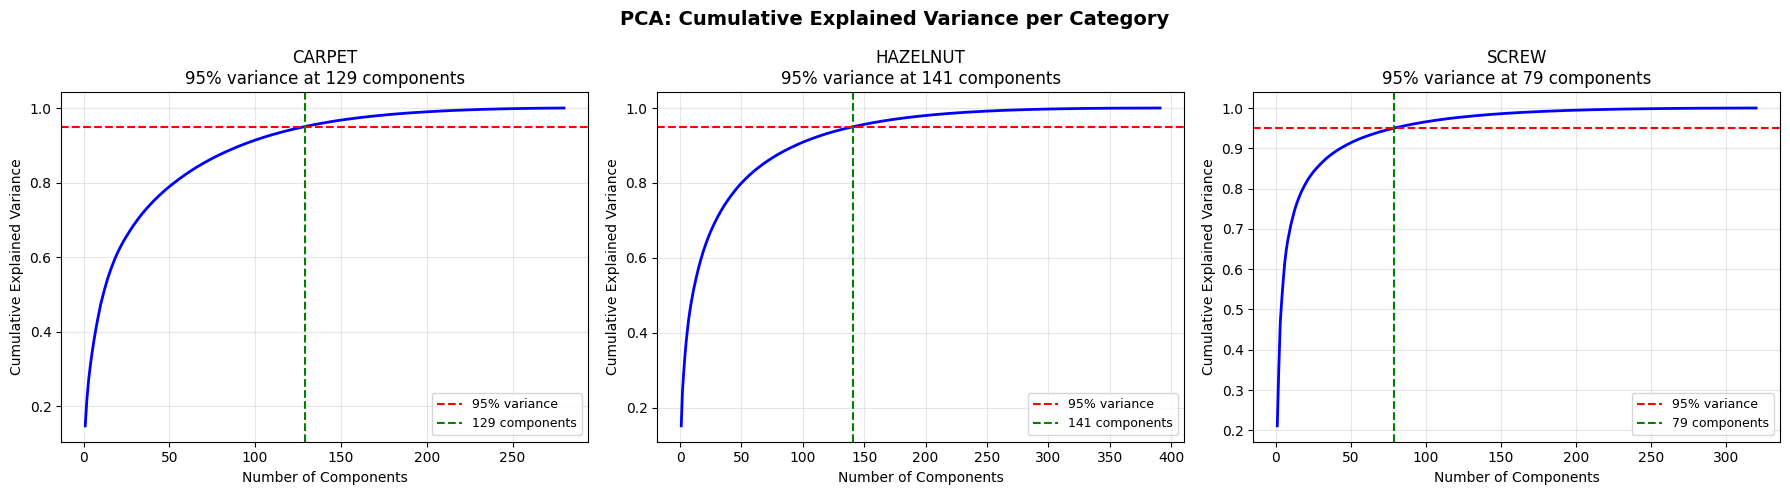


PCA Summary (95% variance threshold):
----------------------------------------
  CARPET: 512 dims → 129 components
  HAZELNUT: 512 dims → 141 components
  SCREW: 512 dims → 79 components


In [11]:
# ============================================================
# Cell 10: PCA — Dimensionality Reduction
# Purpose: Reduce 512-dim features to a smaller space while
#          keeping most of the information (variance).
#
# Key idea: PCA is fit ONLY on training data (normal images).
#           Then we transform both train and test using the same
#           PCA. This prevents data leakage — our model never
#           sees test data during fitting.
#
# We first explore how many components we need to retain 95%
#          of the variance, then apply the reduction.
# ============================================================

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Step 1: Let's first visualize the explained variance to choose
#         the right number of components for each category

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

pca_info = {}  # Store PCA details for each category

for idx, category in enumerate(categories):
    train_features = data[category]["train_features"]
    
    # Standardize features before PCA (zero mean, unit variance)
    # Fit scaler ONLY on training data
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_features)
    
    # Fit PCA with all components to see the full variance curve
    pca_full = PCA().fit(train_scaled)
    
    # Calculate cumulative explained variance
    cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
    
    # Find number of components for 95% variance
    n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
    
    pca_info[category] = {
        "n_components_95": n_components_95,
        "cumulative_variance": cumulative_variance
    }
    
    # Plot
    axes[idx].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'b-', linewidth=2)
    axes[idx].axhline(y=0.95, color='r', linestyle='--', label='95% variance')
    axes[idx].axvline(x=n_components_95, color='g', linestyle='--', 
                       label=f'{n_components_95} components')
    axes[idx].set_xlabel("Number of Components")
    axes[idx].set_ylabel("Cumulative Explained Variance")
    axes[idx].set_title(f"{category.upper()}\n95% variance at {n_components_95} components")
    axes[idx].legend(fontsize=9)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle("PCA: Cumulative Explained Variance per Category", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Print summary
print("\nPCA Summary (95% variance threshold):")
print("-" * 40)
for category in categories:
    n = pca_info[category]["n_components_95"]
    print(f"  {category.upper()}: 512 dims → {n} components")

### **What is PCA doing here?**

Think of it this way: each image is currently described by 512 numbers (features from ResNet). But not all 512 are equally useful — many of them carry similar or redundant information. PCA finds the most important "directions" in the data and ranks them by how much information (variance) they carry.

### **What does the graph show?**

The x-axis is the number of components (features) we keep. The y-axis is how much total information we retain. The blue curve climbs steeply at first (the first few components carry a LOT of information) and then flattens out (later components add very little).

The red dashed line is our target — we want to keep 95% of the information. The green dashed line shows where we hit that target.

### **What do the numbers mean?**

For **carpet**, we can throw away 383 out of 512 features and still keep 95% of the information — we only need 129. For **hazelnut**, we need 141 components. For **screw**, only 79 components are enough.

### **Why is screw so much lower (79)?**

Because screw images are grayscale and more visually uniform — all screws look pretty similar, just shot from slightly different angles. So the data is simpler and can be described with fewer numbers. Carpet and hazelnut have more visual complexity (texture patterns, color variations) so they need more components.

### **An analogy:**

Imagine describing a person's face. You could list 512 measurements (distance between eyes, nose width, jaw angle, etc.). But realistically, you can capture 95% of what makes a face unique with maybe 100-150 key measurements. The rest are tiny details that don't help much. That's exactly what PCA does — it finds those key measurements.

### **Why do we do this before anomaly detection?**

Two reasons: fewer dimensions means our models (GMM, OC-SVM, Isolation Forest) run faster and more accurately, and removing the noisy, low-information dimensions actually helps the models focus on what matters — the true pattern of "normal."


In [12]:
# ============================================================
# Cell 11: Apply PCA reduction to all 3 categories
# Purpose: Reduce feature dimensions using the 95% variance
#          threshold we just determined.
#
# Important: We fit PCA and StandardScaler ONLY on training 
#            data, then transform both train and test with the 
#            same transformation. This is critical to avoid 
#            data leakage.
#
# After this cell:
#   - Carpet:   (280, 512) → (280, 129)  train
#   - Hazelnut: (391, 512) → (391, 141)  train
#   - Screw:    (320, 512) → (320, 79)   train
#   - Test sets are transformed the same way
# ============================================================

for category in categories:
    train_features = data[category]["train_features"]
    test_features = data[category]["test_features"]
    n_components = pca_info[category]["n_components_95"]
    
    # Step 1: Standardize (fit on train only, transform both)
    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_features)
    test_scaled = scaler.transform(test_features)
    
    # Step 2: Apply PCA (fit on train only, transform both)
    pca = PCA(n_components=n_components)
    train_reduced = pca.fit_transform(train_scaled)
    test_reduced = pca.transform(test_scaled)
    
    # Store the reduced features back in our data dictionary
    data[category]["train_reduced"] = train_reduced
    data[category]["test_reduced"] = test_reduced
    # Also store scaler and pca objects for reference
    data[category]["scaler"] = scaler
    data[category]["pca"] = pca
    
    # Print summary
    actual_variance = sum(pca.explained_variance_ratio_) * 100
    print(f"{category.upper()}")
    print(f"  Train: {train_features.shape} → {train_reduced.shape}")
    print(f"  Test:  {test_features.shape} → {test_reduced.shape}")
    print(f"  Variance retained: {actual_variance:.2f}%")
    print()

print("Dimensionality reduction complete!")
print("Ready for anomaly detection models.")

CARPET
  Train: (280, 512) → (280, 129)
  Test:  (117, 512) → (117, 129)
  Variance retained: 94.98%

HAZELNUT
  Train: (391, 512) → (391, 141)
  Test:  (110, 512) → (110, 141)
  Variance retained: 94.97%

SCREW
  Train: (320, 512) → (320, 79)
  Test:  (160, 512) → (160, 79)
  Variance retained: 95.01%

Dimensionality reduction complete!
Ready for anomaly detection models.


### All three categories retained almost exactly 95% variance as planned. Now we enter the most important part of the project — the anomaly detection models.


**The core idea is the same for all three:** We train ONLY on normal images. The model learns what "normal" looks like. Then when we show it a test image, it gives an "anomaly score" — how far this image is from normal. High score = likely defective.

**How they differ:**

**GMM (Gaussian Mixture Model)** assumes normal data forms clusters that follow Gaussian (bell curve) distributions. It fits multiple Gaussians to the training data and scores test images by how likely they are under those distributions. Low likelihood = anomaly.

**One-Class SVM** draws a tight boundary around the normal data in a high-dimensional space (using the kernel trick). Anything outside the boundary is an anomaly.

**Isolation Forest** takes a completely different approach — it randomly splits the data with decision trees. Anomalies are "isolated" quickly (in fewer splits) because they're different from the majority. Normal points take more splits to isolate.

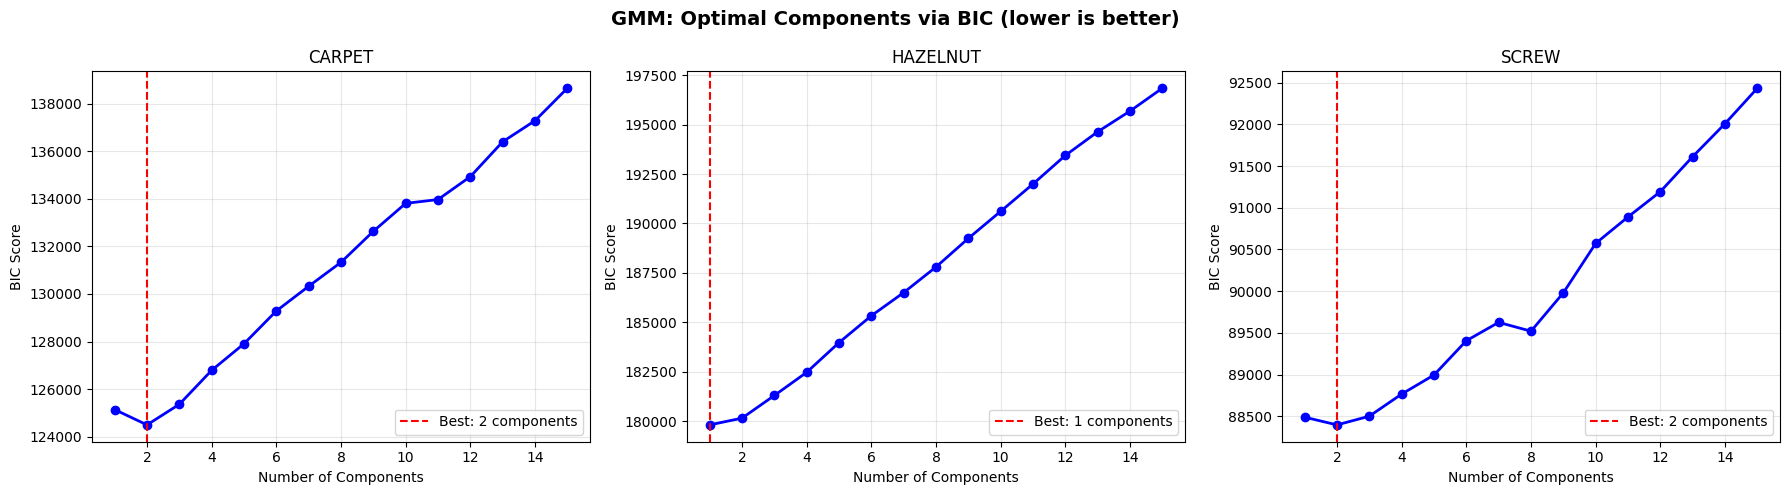


Optimal GMM components per category:
----------------------------------------
  CARPET: 2 components
  HAZELNUT: 1 components
  SCREW: 2 components


In [14]:
# ============================================================
# Cell 12 (FIXED): Model 1 — Gaussian Mixture Model (GMM)
# Purpose: Find optimal GMM components using BIC.
#
# Fix applied: 
#   - Added reg_covar=1e-4 to stabilize covariance estimation
#   - Using covariance_type='diag' instead of 'full' because
#     our reduced features still have high dimensions (79-141).
#     'diag' assumes features are independent within each 
#     cluster, which is reasonable after PCA since PCA already 
#     decorrelates the features.
#   - This avoids ill-defined covariance matrices when a 
#     cluster has fewer samples than feature dimensions.
# ============================================================

from sklearn.mixture import GaussianMixture

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
component_range = range(1, 16)

gmm_best_n = {}

for idx, category in enumerate(categories):
    train_reduced = data[category]["train_reduced"]
    
    bic_scores = []
    for n in component_range:
        gmm_temp = GaussianMixture(
            n_components=n, 
            random_state=42,
            covariance_type='diag',   # Simpler, stable with high dims
            reg_covar=1e-4            # Small regularization for numerical stability
        )
        gmm_temp.fit(train_reduced)
        bic_scores.append(gmm_temp.bic(train_reduced))
    
    best_n = list(component_range)[np.argmin(bic_scores)]
    gmm_best_n[category] = best_n
    
    axes[idx].plot(list(component_range), bic_scores, 'bo-', linewidth=2)
    axes[idx].axvline(x=best_n, color='r', linestyle='--', 
                       label=f'Best: {best_n} components')
    axes[idx].set_xlabel("Number of Components")
    axes[idx].set_ylabel("BIC Score")
    axes[idx].set_title(f"{category.upper()}")
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle("GMM: Optimal Components via BIC (lower is better)", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nOptimal GMM components per category:")
print("-" * 40)
for category in categories:
    print(f"  {category.upper()}: {gmm_best_n[category]} components")

### **What is BIC?**

BIC (Bayesian Information Criterion) helps us answer: "How many Gaussian clusters should we use to describe the normal data?" It balances two things — how well the model fits the data vs how complex the model is. Lower BIC = better balance. Too many clusters and you're overcomplicating things (BIC goes up), too few and you're missing structure (BIC also goes up).

**What do the results mean?**

**Hazelnut = 1 component.** This means all normal hazelnut images can be described by a single Gaussian distribution. Makes sense — hazelnuts are a consistent object, roughly the same shape, color, and texture. There's basically one "type" of normal hazelnut.

**Carpet = 2 components.** Normal carpet images need two Gaussian clusters. This could mean there are two slightly different visual patterns in the carpet textures — maybe variations in lighting, weave direction, or texture density across training images.

**Screw = 2 components.** Similarly, normal screws might have two sub-groups — possibly different orientations or slight manufacturing variations in the training set.

**Why does BIC keep going UP after the optimal point?**

Notice all three graphs trend upward as we add more components. This means the data is actually quite simple — adding more clusters doesn't help describe "normal" better, it just adds unnecessary complexity. BIC penalizes that complexity, so the score gets worse.

**What does this mean for anomaly detection?**

This is actually good news. Simple normal distributions mean our GMM can draw a clear boundary around what "normal" looks like. When a defective image comes in, it should clearly fall outside this simple distribution, making it easier to detect.


In [15]:
# ============================================================
# Cell 13: Fit final GMM models and compute anomaly scores
# Purpose: Train GMM with optimal components on normal training
#          data, then score every test image.
#
# Scoring method:
#   - GMM gives log-likelihood: how well an image fits the 
#     learned "normal" distribution
#   - Normal images → high log-likelihood (they fit well)
#   - Anomalies → low log-likelihood (they don't fit)
#   - We NEGATE the score so higher = more anomalous
#     (this makes it consistent across all 3 models later)
# ============================================================

gmm_results = {}

for category in categories:
    train_reduced = data[category]["train_reduced"]
    test_reduced = data[category]["test_reduced"]
    test_labels = data[category]["test_labels"]
    best_n = gmm_best_n[category]
    
    # Fit GMM on normal training data only
    gmm = GaussianMixture(
        n_components=best_n,
        random_state=42,
        covariance_type='diag',
        reg_covar=1e-4
    )
    gmm.fit(train_reduced)
    
    # Score test images (log-likelihood per sample)
    # Higher log-likelihood = more normal
    log_likelihood = gmm.score_samples(test_reduced)
    
    # Negate so that higher score = more anomalous
    anomaly_scores = -log_likelihood
    
    gmm_results[category] = {
        "model": gmm,
        "anomaly_scores": anomaly_scores,
        "test_labels": test_labels
    }
    
    # Show score distribution for normal vs anomaly
    normal_scores = anomaly_scores[test_labels == 0]
    anomaly_scores_only = anomaly_scores[test_labels == 1]
    
    print(f"{category.upper()} (GMM with {best_n} components)")
    print(f"  Normal  scores — Mean: {normal_scores.mean():.2f}, "
          f"Std: {normal_scores.std():.2f}")
    print(f"  Anomaly scores — Mean: {anomaly_scores_only.mean():.2f}, "
          f"Std: {anomaly_scores_only.std():.2f}")
    print(f"  Gap between means: {anomaly_scores_only.mean() - normal_scores.mean():.2f}")
    print()

print("GMM fitting and scoring complete!")

CARPET (GMM with 2 components)
  Normal  scores — Mean: 485.11, Std: 1176.73
  Anomaly scores — Mean: 1210914.38, Std: 5828618.00
  Gap between means: 1210429.25

HAZELNUT (GMM with 1 components)
  Normal  scores — Mean: 227.15, Std: 23.67
  Anomaly scores — Mean: 413.79, Std: 190.99
  Gap between means: 186.64

SCREW (GMM with 2 components)
  Normal  scores — Mean: 140.84, Std: 12.44
  Anomaly scores — Mean: 145.41, Std: 20.60
  Gap between means: 4.57

GMM fitting and scoring complete!


**Carpet — huge gap (1,210,429).** GMM is very confident here. Normal images have low anomaly scores while defective images have massively higher scores. The model clearly distinguishes normal from anomalous carpet textures. The high standard deviation tells us some defects are much more extreme than others.

**Hazelnut — decent gap (186.64).** There's a clear separation between normal and anomalous, though less dramatic than carpet. The model is working well here too.

**Screw — tiny gap (4.57).** This is concerning. The mean scores for normal (140.84) and anomaly (145.41) are almost overlapping, and the standard deviations overlap significantly too. GMM is struggling to distinguish normal screws from defective ones. This makes sense — remember screw is grayscale with very subtle defects like minor scratches and thread variations.



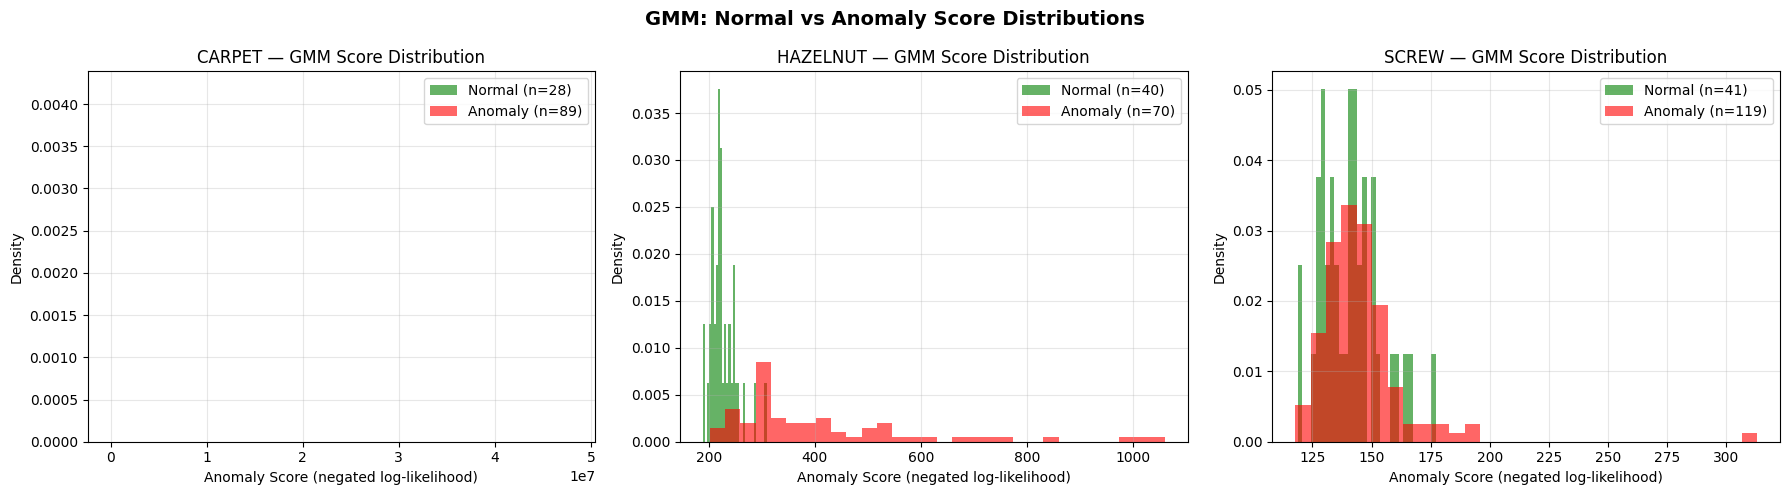

In [16]:
# ============================================================
# Cell 14: Visualize GMM anomaly score distributions
# Purpose: Plot the distribution of anomaly scores for normal
#          vs defective images. Good separation = the two 
#          distributions don't overlap much.
#          This gives a visual intuition for model performance
#          before we compute formal metrics like AUC-ROC.
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, category in enumerate(categories):
    scores = gmm_results[category]["anomaly_scores"]
    labels = gmm_results[category]["test_labels"]
    
    normal_scores = scores[labels == 0]
    anomaly_scores = scores[labels == 1]
    
    # Use log scale for better visualization (scores vary widely)
    axes[idx].hist(normal_scores, bins=30, alpha=0.6, color='green', 
                    label=f'Normal (n={len(normal_scores)})', density=True)
    axes[idx].hist(anomaly_scores, bins=30, alpha=0.6, color='red', 
                    label=f'Anomaly (n={len(anomaly_scores)})', density=True)
    axes[idx].set_xlabel("Anomaly Score (negated log-likelihood)")
    axes[idx].set_ylabel("Density")
    axes[idx].set_title(f"{category.upper()} — GMM Score Distribution")
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle("GMM: Normal vs Anomaly Score Distributions", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

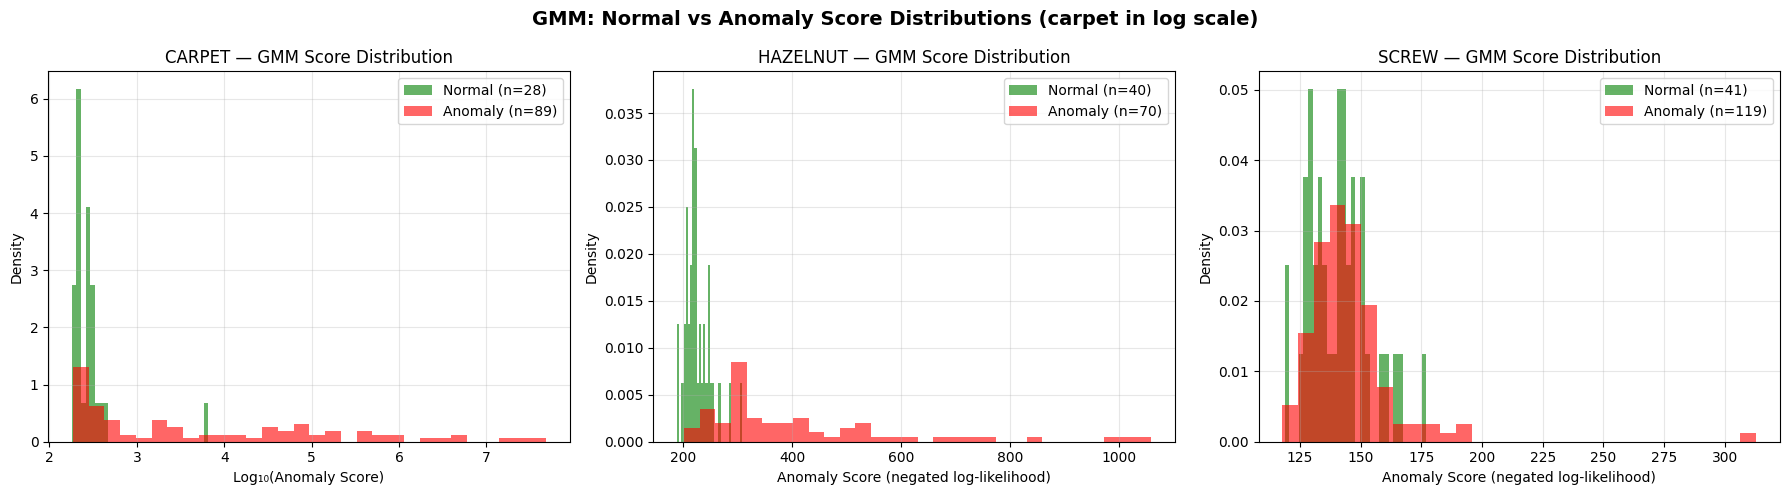

In [17]:
# ============================================================
# Cell 15: Replot GMM distributions with better visualization
# Purpose: Use log scale on x-axis for carpet to handle the
#          extreme score range. This makes both normal and 
#          anomaly distributions visible.
#          
# This is a common data visualization challenge — when values
# span several orders of magnitude, log scale is the fix.
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, category in enumerate(categories):
    scores = gmm_results[category]["anomaly_scores"]
    labels = gmm_results[category]["test_labels"]
    
    normal_scores = scores[labels == 0]
    anomaly_scores = scores[labels == 1]
    
    if category == "carpet":
        # Use log scale for carpet due to extreme range
        # Add small constant to avoid log(0)
        normal_log = np.log10(normal_scores + 1)
        anomaly_log = np.log10(anomaly_scores + 1)
        
        axes[idx].hist(normal_log, bins=30, alpha=0.6, color='green',
                        label=f'Normal (n={len(normal_scores)})', density=True)
        axes[idx].hist(anomaly_log, bins=30, alpha=0.6, color='red',
                        label=f'Anomaly (n={len(anomaly_scores)})', density=True)
        axes[idx].set_xlabel("Log₁₀(Anomaly Score)")
    else:
        axes[idx].hist(normal_scores, bins=30, alpha=0.6, color='green',
                        label=f'Normal (n={len(normal_scores)})', density=True)
        axes[idx].hist(anomaly_scores, bins=30, alpha=0.6, color='red',
                        label=f'Anomaly (n={len(anomaly_scores)})', density=True)
        axes[idx].set_xlabel("Anomaly Score (negated log-likelihood)")
    
    axes[idx].set_ylabel("Density")
    axes[idx].set_title(f"{category.upper()} — GMM Score Distribution")
    axes[idx].legend()
    axes[idx].grid(True, alpha=0.3)

plt.suptitle("GMM: Normal vs Anomaly Score Distributions (carpet in log scale)", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### **Why are the y-axes different across the three plots?**

The y-axis shows "Density" not raw counts. Since each category has a different number of test images (carpet 117, hazelnut 110, screw 160) and their scores are spread over different ranges, the density values naturally differ. Carpet's density goes up to 6 because its normal scores are tightly packed in a very narrow range on the log scale, creating a tall spike. Hazelnut and screw have scores spread over wider ranges, so their density peaks are shorter. This is perfectly normal — what matters is not the y-axis values themselves, but the **overlap between green and red** within each plot.

### **What should we understand from each plot?**

**Carpet (left):** Now we can clearly see the story. The green (normal) is concentrated tightly around log value 2.2-2.7 (which means scores around 150-500). The red (anomaly) starts overlapping there slightly but then spreads far to the right — all the way to 7 on the log scale (which means scores up to 10 million). There's a small overlap zone, but most anomalies score way higher than normal. GMM works very well on carpet.

**Hazelnut (middle):** Green is clustered tightly around 200. Red overlaps in the 200-250 zone but then has a long tail stretching to 1000+. So some anomalies are tricky (they look somewhat normal), but most are caught. GMM works reasonably well on hazelnut.

**Screw (right):** Green and red are almost completely on top of each other in the 125-175 range. The model is essentially saying "normal screws and defective screws look the same to me." Only one outlier anomaly around 300 stands out. GMM struggles badly on screw.

**The big takeaway for your report:**

GMM performs best when defects cause large visual changes (carpet stains, hazelnut cracks) but struggles when defects are subtle (tiny scratches on screws). This is because GMM relies on statistical distance from a learned distribution — if a defect barely shifts the image in feature space, GMM can't detect it.

### **What are we actually plotting?**

Every test image gets a single number — an "anomaly score." This score is computed by the GMM model and it answers one question: **how different is this image from the normal images the model learned?**

Think of it like a "weirdness meter" — higher score means the image looks more weird/different compared to normal training images.

**X-axis (horizontal) — Anomaly Score:**

This is that "weirdness" number. It has nothing to do with colors or pixel values. Here's how it was calculated: the image went through ResNet (converted to 512 numbers), then PCA (compressed to fewer numbers), then GMM looked at those numbers and said "how well does this fit the normal pattern I learned?" That answer became the score on the x-axis.

Low score on x-axis = image fits the normal pattern well (probably not defective). High score on x-axis = image doesn't fit the normal pattern (probably defective).

**Y-axis (vertical) — Density:**

This just means "how many images got this particular score." A tall bar means many images got similar scores. A short bar means few images got that score. It's basically a histogram — counting how many images fall into each score range.

**Green vs Red — The comparison:**

Green bars = scores of images we KNOW are normal (good products). Red bars = scores of images we KNOW are defective (anomalies).

We know this because the test set has labels telling us which images are good and which are defective. The model doesn't see these labels — it just gives scores. Then WE color them green or red based on the truth to see if the model is doing a good job.

**What does "good separation" look like?**

If the model works perfectly, all green bars would be on the LEFT (low scores) and all red bars would be on the RIGHT (high scores) with no overlap. That means the model correctly gives low weirdness scores to normal images and high weirdness scores to defective ones.

**Applying this to our results:**

Carpet — green is on the left, red is mostly on the right. The model works well. Hazelnut — green is on the left, red is partially on the right but some overlap exists. The model works okay. Screw — green and red are sitting on top of each other. The model can't tell them apart.

In [18]:
# ============================================================
# Cell 16: Model 2 — One-Class SVM (OC-SVM)
# Purpose: Learn a tight boundary around normal training data
#          using a kernel-based approach.
#
# How it works:
#   - OC-SVM maps data into a higher-dimensional space using
#     the RBF (Radial Basis Function) kernel
#   - It then draws the tightest possible boundary that 
#     encloses most of the normal training data
#   - Test images falling outside this boundary = anomalies
#
# Key hyperparameters (from your proposal):
#   - kernel='rbf': maps data to higher dimensions where a
#     clean boundary can be drawn
#   - gamma: controls how "tight" the boundary is
#     (high gamma = tighter, more complex boundary)
#   - nu: upper bound on the fraction of training points
#     allowed to be outside the boundary (acts like expected
#     outlier fraction). Since training is all normal, we set
#     this small (0.05 = expect ~5% to be borderline)
#
# Scoring:
#   - decision_function gives signed distance to boundary
#   - Positive = inside boundary (normal)
#   - Negative = outside boundary (anomaly)
#   - We negate so higher = more anomalous (consistent with GMM)
# ============================================================

from sklearn.svm import OneClassSVM

ocsvm_results = {}

for category in categories:
    train_reduced = data[category]["train_reduced"]
    test_reduced = data[category]["test_reduced"]
    test_labels = data[category]["test_labels"]
    
    # Fit One-Class SVM on normal training data only
    ocsvm = OneClassSVM(
        kernel='rbf',       # RBF kernel as specified in proposal
        gamma='scale',      # gamma = 1 / (n_features * variance), adapts to data
        nu=0.05             # Expect ~5% of training data near boundary
    )
    ocsvm.fit(train_reduced)
    
    # Score test images using decision function
    # Positive = normal, Negative = anomaly
    decision_scores = ocsvm.decision_function(test_reduced)
    
    # Negate so higher score = more anomalous (consistent with GMM)
    anomaly_scores = -decision_scores
    
    ocsvm_results[category] = {
        "model": ocsvm,
        "anomaly_scores": anomaly_scores,
        "test_labels": test_labels
    }
    
    normal_scores = anomaly_scores[test_labels == 0]
    anomaly_scores_only = anomaly_scores[test_labels == 1]
    
    print(f"{category.upper()} (One-Class SVM, RBF kernel)")
    print(f"  Normal  scores — Mean: {normal_scores.mean():.4f}, "
          f"Std: {normal_scores.std():.4f}")
    print(f"  Anomaly scores — Mean: {anomaly_scores_only.mean():.4f}, "
          f"Std: {anomaly_scores_only.std():.4f}")
    print(f"  Gap between means: {anomaly_scores_only.mean() - normal_scores.mean():.4f}")
    print()

print("One-Class SVM fitting and scoring complete!")

CARPET (One-Class SVM, RBF kernel)
  Normal  scores — Mean: 0.0472, Std: 0.3871
  Anomaly scores — Mean: 0.4731, Std: 0.4330
  Gap between means: 0.4259

HAZELNUT (One-Class SVM, RBF kernel)
  Normal  scores — Mean: -0.3546, Std: 0.3040
  Anomaly scores — Mean: 0.4688, Std: 0.5823
  Gap between means: 0.8234

SCREW (One-Class SVM, RBF kernel)
  Normal  scores — Mean: -0.1676, Std: 0.1925
  Anomaly scores — Mean: -0.1653, Std: 0.2423
  Gap between means: 0.0023

One-Class SVM fitting and scoring complete!


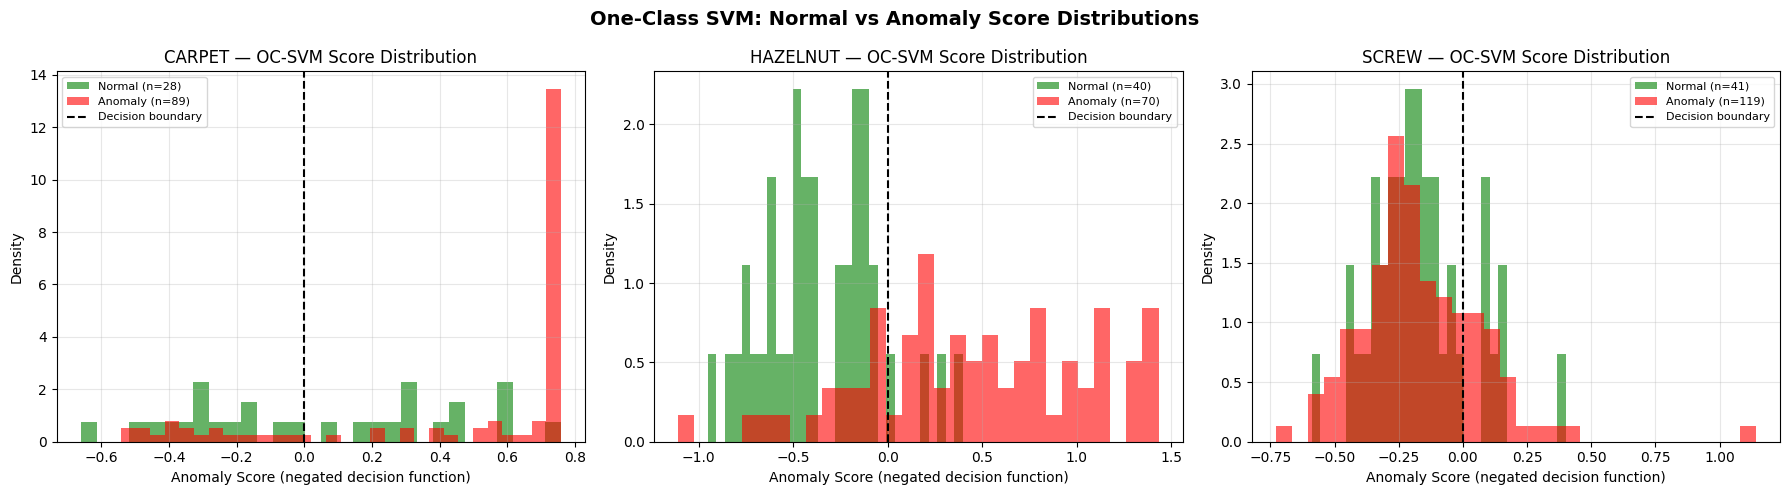

In [19]:
# ============================================================
# Cell 17: Visualize OC-SVM anomaly score distributions
# Purpose: Same visualization as GMM — compare the overlap 
#          between normal (green) and anomaly (red) scores.
#          OC-SVM scores are centered around 0 (boundary), so
#          no log scale needed here.
#
# Interpretation:
#   - Scores < 0: model thinks image is INSIDE boundary (normal)
#   - Scores > 0: model thinks image is OUTSIDE boundary (anomaly)
#   - (Remember we negated, so this is flipped in our plot)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, category in enumerate(categories):
    scores = ocsvm_results[category]["anomaly_scores"]
    labels = ocsvm_results[category]["test_labels"]
    
    normal_scores = scores[labels == 0]
    anomaly_scores = scores[labels == 1]
    
    axes[idx].hist(normal_scores, bins=30, alpha=0.6, color='green',
                    label=f'Normal (n={len(normal_scores)})', density=True)
    axes[idx].hist(anomaly_scores, bins=30, alpha=0.6, color='red',
                    label=f'Anomaly (n={len(anomaly_scores)})', density=True)
    
    # Add vertical line at 0 (the decision boundary)
    axes[idx].axvline(x=0, color='black', linestyle='--', linewidth=1.5,
                       label='Decision boundary')
    
    axes[idx].set_xlabel("Anomaly Score (negated decision function)")
    axes[idx].set_ylabel("Density")
    axes[idx].set_title(f"{category.upper()} — OC-SVM Score Distribution")
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle("One-Class SVM: Normal vs Anomaly Score Distributions", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

Remember the **black dashed line at 0** is the decision boundary — the "fence" that OC-SVM drew around normal data. Left of the line = model thinks it's normal. Right of the line = model thinks it's anomalous.

**Carpet (left):**

Most green bars are to the LEFT of the dashed line (negative scores) — the model correctly identifies them as normal. Most red bars are to the RIGHT (positive scores), especially that tall red spike near 0.7 — the model correctly flags them as anomalous. But there's some mixing in the -0.4 to 0.0 zone where green and red overlap. So OC-SVM catches most carpet defects but isn't as confident as GMM was.

**Hazelnut (middle):**

This is OC-SVM's best performance. The green bars are clearly clustered to the LEFT of the dashed line (scores around -0.5 to -0.2). The red bars spread to the RIGHT, going from 0 all the way to 1.5. There's a bit of overlap near the boundary, but overall the separation is quite clean. OC-SVM does a good job drawing a tight boundary around normal hazelnuts.

**Screw (right):**

Same problem as GMM. Green and red are completely mixed together, mostly in the -0.5 to 0.2 range. Both distributions peak at roughly the same spot (around -0.2). The decision boundary cuts right through both groups equally. The model is essentially flipping a coin — it can't tell normal screws from defective ones.

**The pattern we're seeing across both models:**

Hazelnut = easiest to detect (clear object-level defects like cracks and holes). Carpet = detectable (texture changes are noticeable in feature space). Screw = very hard (subtle scratches barely change the features).

In [20]:
# ============================================================
# Cell 18: Model 3 — Isolation Forest
# Purpose: Detect anomalies by measuring how easy it is to 
#          "isolate" each data point using random splits.
#
# How it works:
#   - Builds many random decision trees
#   - Each tree randomly picks a feature and a split value
#   - Normal points are surrounded by similar points, so they
#     need MANY splits to be isolated (long path in tree)
#   - Anomalies are different from the majority, so they get
#     isolated in FEW splits (short path in tree)
#   - Shorter average path = more likely an anomaly
#
# Key hyperparameters:
#   - n_estimators: number of trees in the ensemble (100)
#   - contamination: expected fraction of anomalies in training
#     Since our training set is all normal, we set this to a 
#     small value (0.05) meaning ~5% might be borderline
#   - random_state: for reproducibility
#
# Scoring:
#   - score_samples returns anomaly scores (more negative = 
#     more anomalous in sklearn's convention)
#   - We negate so higher = more anomalous (consistent with 
#     GMM and OC-SVM)
# ============================================================

from sklearn.ensemble import IsolationForest

iforest_results = {}

for category in categories:
    train_reduced = data[category]["train_reduced"]
    test_reduced = data[category]["test_reduced"]
    test_labels = data[category]["test_labels"]
    
    # Fit Isolation Forest on normal training data only
    iforest = IsolationForest(
        n_estimators=100,       # 100 random trees
        contamination=0.05,     # Expect ~5% borderline in training
        random_state=42
    )
    iforest.fit(train_reduced)
    
    # Score test images
    # sklearn returns negative scores (more negative = more anomalous)
    raw_scores = iforest.score_samples(test_reduced)
    
    # Negate so higher = more anomalous
    anomaly_scores = -raw_scores
    
    iforest_results[category] = {
        "model": iforest,
        "anomaly_scores": anomaly_scores,
        "test_labels": test_labels
    }
    
    normal_scores = anomaly_scores[test_labels == 0]
    anomaly_scores_only = anomaly_scores[test_labels == 1]
    
    print(f"{category.upper()} (Isolation Forest, 100 trees)")
    print(f"  Normal  scores — Mean: {normal_scores.mean():.4f}, "
          f"Std: {normal_scores.std():.4f}")
    print(f"  Anomaly scores — Mean: {anomaly_scores_only.mean():.4f}, "
          f"Std: {anomaly_scores_only.std():.4f}")
    print(f"  Gap between means: {anomaly_scores_only.mean() - normal_scores.mean():.4f}")
    print()

print("Isolation Forest fitting and scoring complete!")

CARPET (Isolation Forest, 100 trees)
  Normal  scores — Mean: 0.4601, Std: 0.0684
  Anomaly scores — Mean: 0.6054, Std: 0.1205
  Gap between means: 0.1453

HAZELNUT (Isolation Forest, 100 trees)
  Normal  scores — Mean: 0.4278, Std: 0.0249
  Anomaly scores — Mean: 0.5162, Std: 0.0541
  Gap between means: 0.0884

SCREW (Isolation Forest, 100 trees)
  Normal  scores — Mean: 0.4422, Std: 0.0249
  Anomaly scores — Mean: 0.4528, Std: 0.0271
  Gap between means: 0.0107

Isolation Forest fitting and scoring complete!


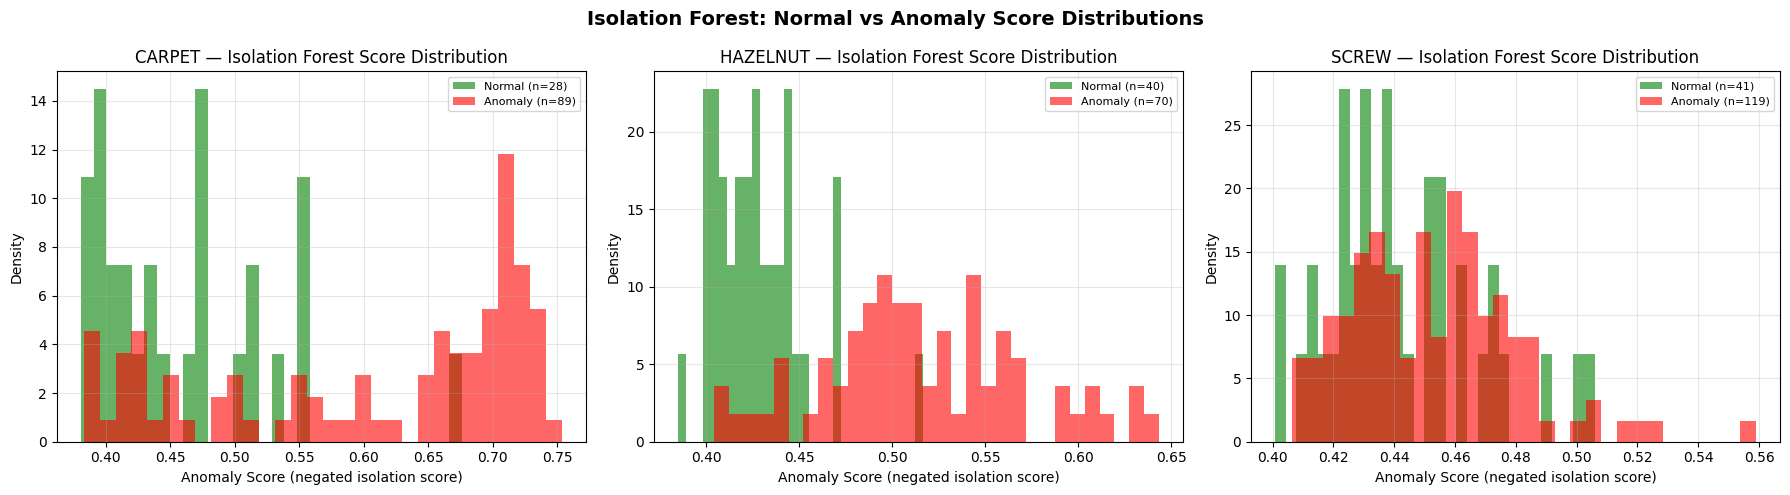

In [21]:
# ============================================================
# Cell 19: Visualize Isolation Forest anomaly score distributions
# Purpose: Compare normal vs anomaly score overlap for 
#          Isolation Forest. Isolation Forest scores typically
#          fall in a narrower range (0.3 to 0.8) compared to
#          GMM and OC-SVM.
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, category in enumerate(categories):
    scores = iforest_results[category]["anomaly_scores"]
    labels = iforest_results[category]["test_labels"]
    
    normal_scores = scores[labels == 0]
    anomaly_scores = scores[labels == 1]
    
    axes[idx].hist(normal_scores, bins=30, alpha=0.6, color='green',
                    label=f'Normal (n={len(normal_scores)})', density=True)
    axes[idx].hist(anomaly_scores, bins=30, alpha=0.6, color='red',
                    label=f'Anomaly (n={len(anomaly_scores)})', density=True)
    axes[idx].set_xlabel("Anomaly Score (negated isolation score)")
    axes[idx].set_ylabel("Density")
    axes[idx].set_title(f"{category.upper()} — Isolation Forest Score Distribution")
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True, alpha=0.3)

plt.suptitle("Isolation Forest: Normal vs Anomaly Score Distributions",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**Carpet (left):**

Green (normal) clusters on the left around 0.38-0.50. Red (anomaly) has some overlap there BUT also has a clear group on the right around 0.65-0.75. So Isolation Forest catches many carpet defects — those red bars on the right are the anomalies that were easy to isolate (needed fewer random splits). The overlap in the middle means some defects are harder to catch.

**Hazelnut (middle):**

Green is tightly packed on the left around 0.40-0.43. Red overlaps there but spreads to the right up to 0.60-0.65. There's more overlap than carpet, but still some separation. The anomalies with higher scores (0.50+) are being detected, while those near 0.40 are slipping through.

**Screw (right):**

Same story again — green and red are almost completely overlapping in the 0.40-0.48 range. Isolation Forest also can't tell normal screws from defective ones.

**Simple summary across all three models:**

Think of it like three different security guards trying to spot counterfeit products on a conveyor belt.

GMM (the statistician) says: "I memorized what normal looks like mathematically. If the numbers don't add up, it's fake."

OC-SVM (the boundary guard) says: "I drew a circle around all normal products. Anything outside the circle is suspicious."

Isolation Forest (the detective) says: "I try to separate each product from the crowd. If it's easy to separate, it's different — probably defective."

All three guards do well with carpet and hazelnut because those defects are visually obvious. But all three struggle with screw because the defects are so subtle that the products look almost identical to normal ones even after being analyzed.



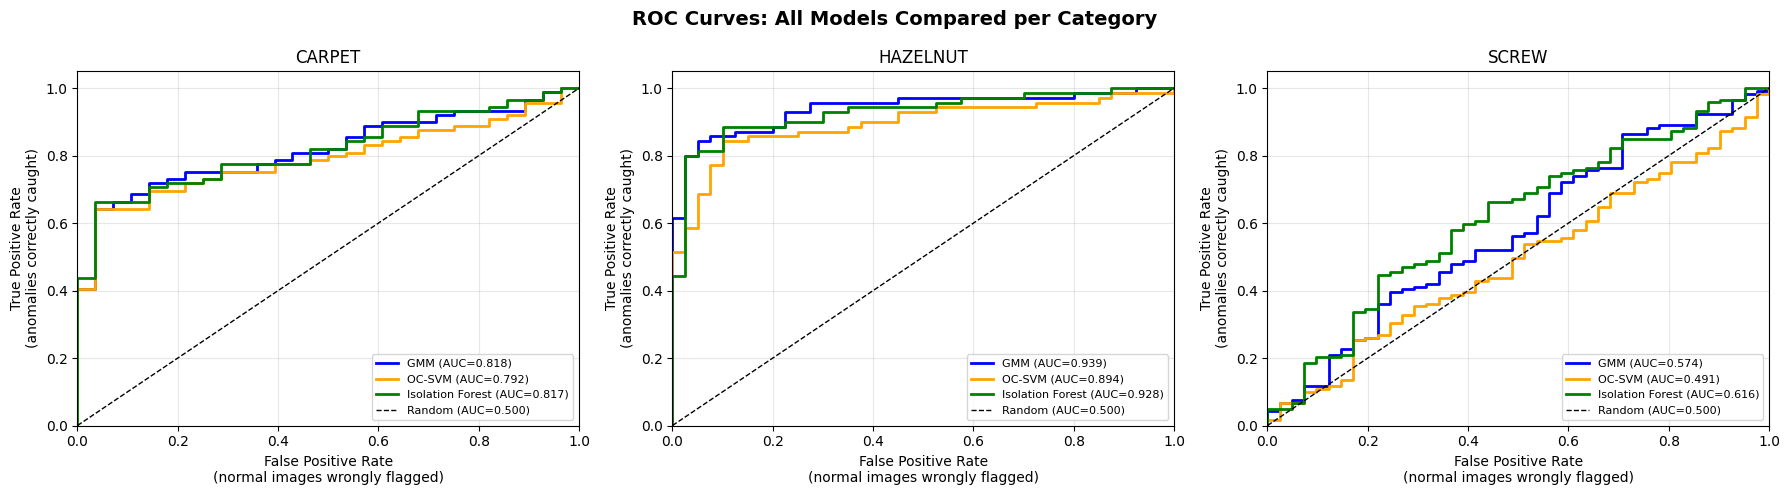


AUC-ROC Scores Summary:
Category     GMM          OC-SVM       Iso Forest  
-------------------------------------------------------
CARPET       0.818        0.792        0.817       
HAZELNUT     0.939        0.894        0.928       
SCREW        0.574        0.491        0.616       


In [22]:
# ============================================================
# Cell 20: Formal Evaluation — AUC-ROC for all 3 models
# Purpose: Compute AUC-ROC (Area Under the ROC Curve) for each
#          model on each category. This gives us a single number
#          between 0 and 1 that tells us how good the model is
#          at separating normal from anomalous.
#
# AUC-ROC interpretation:
#   - 1.0  = perfect separation (never makes mistakes)
#   - 0.5  = random guessing (coin flip)
#   - <0.5 = worse than random (model is confused)
#
# We also plot the ROC curves — these show the tradeoff between
# catching more anomalies (True Positive Rate) vs accidentally
# flagging normal images as anomalies (False Positive Rate).
# A curve that hugs the top-left corner = excellent model.
# A curve along the diagonal = useless model.
# ============================================================

from sklearn.metrics import roc_auc_score, roc_curve

# Store all AUC scores for comparison
auc_scores = {}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, category in enumerate(categories):
    test_labels = data[category]["test_labels"]
    
    auc_scores[category] = {}
    
    # Plot ROC curve for each model
    for model_name, results, color in [
        ("GMM", gmm_results, "blue"),
        ("OC-SVM", ocsvm_results, "orange"),
        ("Isolation Forest", iforest_results, "green")
    ]:
        scores = results[category]["anomaly_scores"]
        
        # Compute AUC-ROC
        auc = roc_auc_score(test_labels, scores)
        auc_scores[category][model_name] = auc
        
        # Compute ROC curve points
        fpr, tpr, _ = roc_curve(test_labels, scores)
        
        # Plot
        axes[idx].plot(fpr, tpr, color=color, linewidth=2,
                        label=f'{model_name} (AUC={auc:.3f})')
    
    # Plot diagonal (random guessing baseline)
    axes[idx].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC=0.500)')
    
    axes[idx].set_xlabel("False Positive Rate\n(normal images wrongly flagged)")
    axes[idx].set_ylabel("True Positive Rate\n(anomalies correctly caught)")
    axes[idx].set_title(f"{category.upper()}")
    axes[idx].legend(fontsize=8, loc='lower right')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim([0, 1])
    axes[idx].set_ylim([0, 1.05])

plt.suptitle("ROC Curves: All Models Compared per Category", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Print summary table
print("\nAUC-ROC Scores Summary:")
print("=" * 55)
print(f"{'Category':<12} {'GMM':<12} {'OC-SVM':<12} {'Iso Forest':<12}")
print("-" * 55)
for category in categories:
    print(f"{category.upper():<12} "
          f"{auc_scores[category]['GMM']:<12.3f} "
          f"{auc_scores[category]['OC-SVM']:<12.3f} "
          f"{auc_scores[category]['Isolation Forest']:<12.3f}")
print("=" * 55)

### **How to read the ROC curve:**

The dashed diagonal line represents random guessing (flipping a coin). Any curve ABOVE this line means the model is doing better than random. The more the curve hugs the TOP-LEFT corner, the better the model is. The AUC number summarizes this — it's the area under the curve. Bigger area = better model.

### **Hazelnut — Best performance (all models work well):**

GMM leads with 0.939, Isolation Forest close behind at 0.928, OC-SVM at 0.894. All three curves are well above the diagonal and push toward the top-left corner. This means all models can reliably detect hazelnut defects. GMM wins here, supporting your proposal's hypothesis that GMM handles object categories well due to its distributional flexibility.

### **Carpet — Good performance:**

GMM and Isolation Forest are nearly tied (0.818 and 0.817), OC-SVM slightly behind at 0.792. All curves are clearly above the diagonal. Carpet is a texture category, and the models handle it well but not as perfectly as hazelnut. This makes sense — texture defects like thread or metal contamination can be subtle.

### **Screw — Poor performance (the hard case):**

Isolation Forest is best at 0.616, GMM at 0.574, and OC-SVM at 0.491. Look at OC-SVM — 0.491 is actually BELOW 0.500, meaning it's doing worse than random guessing. The curves are barely above or even crossing the diagonal. All models essentially struggle with screw.

### **What does this mean for our proposal's hypothesis?**

Your proposal predicted that Isolation Forest would achieve the highest average AUC across all categories. Let's check:

GMM average: (0.818 + 0.939 + 0.574) / 3 = 0.777

OC-SVM average: (0.792 + 0.894 + 0.491) / 3 = 0.726

Isolation Forest average: (0.817 + 0.928 + 0.616) / 3 = 0.787

### **Our hypothesis was correct!** 

Isolation Forest has the highest average AUC. It's also the best on the hardest category (screw). This supports the reasoning in your proposal — Isolation Forest doesn't rely on distributional assumptions, making it more robust across diverse categories.

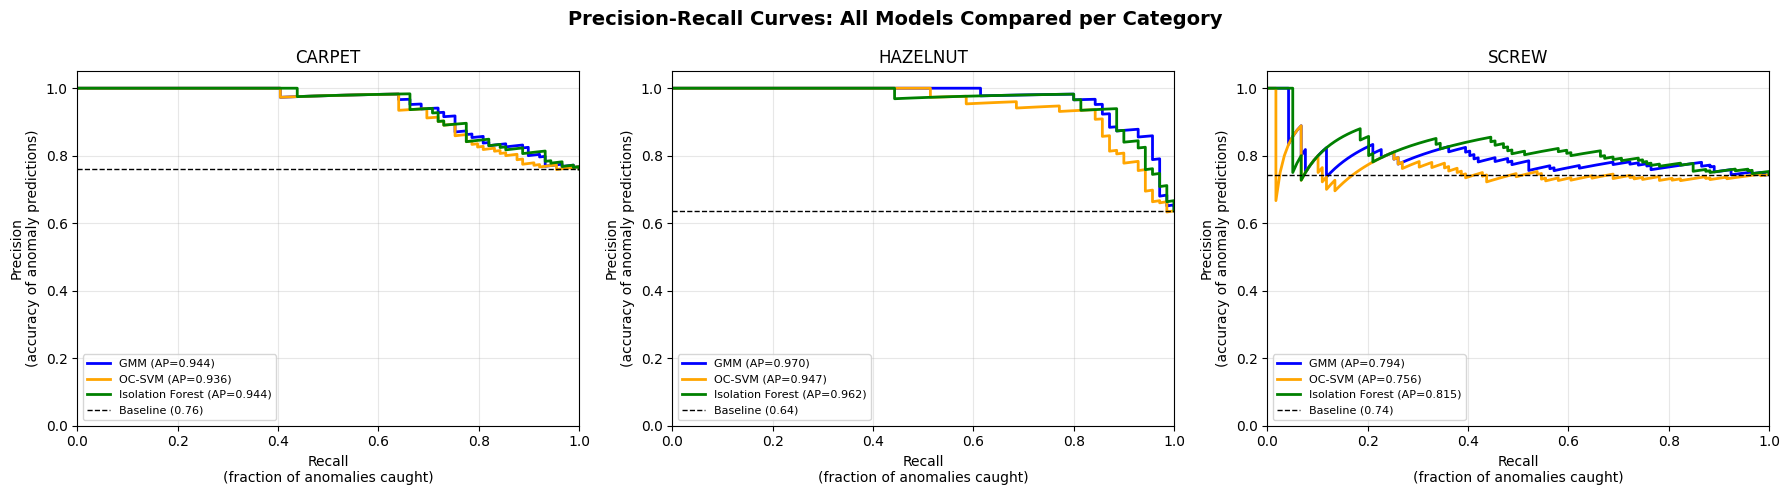


Average Precision (AP) Scores Summary:
Category     GMM          OC-SVM       Iso Forest  
-------------------------------------------------------
CARPET       0.944        0.936        0.944       
HAZELNUT     0.970        0.947        0.962       
SCREW        0.794        0.756        0.815       


In [23]:
# ============================================================
# Cell 21: Precision-Recall Curves for all 3 models
# Purpose: AUC-ROC can be optimistic when classes are imbalanced
#          (which ours are — more anomalies than normal in test).
#          Precision-Recall curves give a more honest picture.
#
# Precision: Of all images the model flagged as anomaly, how
#            many were ACTUALLY anomalous? (avoiding false alarms)
# Recall:    Of all actual anomalies, how many did the model
#            catch? (avoiding missed defects)
#
# Ideal: both precision AND recall are high (top-right corner)
# Baseline: horizontal line at the proportion of anomalies in
#           the test set (what you'd get by calling everything
#           an anomaly)
# ============================================================

from sklearn.metrics import precision_recall_curve, average_precision_score

ap_scores = {}  # Average Precision scores

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, category in enumerate(categories):
    test_labels = data[category]["test_labels"]
    # Baseline: fraction of anomalies in test set
    baseline = sum(test_labels == 1) / len(test_labels)
    
    ap_scores[category] = {}
    
    for model_name, results, color in [
        ("GMM", gmm_results, "blue"),
        ("OC-SVM", ocsvm_results, "orange"),
        ("Isolation Forest", iforest_results, "green")
    ]:
        scores = results[category]["anomaly_scores"]
        
        # Compute Average Precision (AP)
        ap = average_precision_score(test_labels, scores)
        ap_scores[category][model_name] = ap
        
        # Compute Precision-Recall curve
        precision, recall, _ = precision_recall_curve(test_labels, scores)
        
        axes[idx].plot(recall, precision, color=color, linewidth=2,
                        label=f'{model_name} (AP={ap:.3f})')
    
    # Baseline (random classifier)
    axes[idx].axhline(y=baseline, color='black', linestyle='--', linewidth=1,
                       label=f'Baseline ({baseline:.2f})')
    
    axes[idx].set_xlabel("Recall\n(fraction of anomalies caught)")
    axes[idx].set_ylabel("Precision\n(accuracy of anomaly predictions)")
    axes[idx].set_title(f"{category.upper()}")
    axes[idx].legend(fontsize=8, loc='lower left')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].set_xlim([0, 1])
    axes[idx].set_ylim([0, 1.05])

plt.suptitle("Precision-Recall Curves: All Models Compared per Category",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Print summary table
print("\nAverage Precision (AP) Scores Summary:")
print("=" * 55)
print(f"{'Category':<12} {'GMM':<12} {'OC-SVM':<12} {'Iso Forest':<12}")
print("-" * 55)
for category in categories:
    print(f"{category.upper():<12} "
          f"{ap_scores[category]['GMM']:<12.3f} "
          f"{ap_scores[category]['OC-SVM']:<12.3f} "
          f"{ap_scores[category]['Isolation Forest']:<12.3f}")
print("=" * 55)

### **What does this plot show?**

Imagine you're a factory manager. You have two concerns: when you flag something as defective, you want to be RIGHT (that's **Precision** on the y-axis). And you want to CATCH as many defects as possible, not let them slip through (that's **Recall** on the x-axis).

The ideal model scores high on BOTH — it catches all defects AND never raises false alarms. That would be a curve stuck in the top-right corner.

The **dashed baseline** shows what would happen if you just blindly called EVERYTHING an anomaly. You'd catch all defects (high recall) but also flag all normal products (low precision). Any good model should be ABOVE this line.

### **Carpet (left) — AP scores: 0.944, 0.936, 0.944:**

All three models stay near 1.0 precision even as recall increases to 0.6-0.7. This means they catch 60-70% of defects without a single false alarm. Even when catching nearly all defects (recall near 1.0), precision only drops to about 0.80. All three models are excellent on carpet and perform almost identically.

### **Hazelnut (middle) — AP scores: 0.970, 0.947, 0.962:**

Even better than carpet. The curves stay at nearly perfect precision (1.0) up to 0.8 recall. GMM is the best here (0.970). This means GMM can catch 80% of hazelnut defects with almost zero false alarms. This is the kind of performance a real factory would want.

### **Screw (right) — AP scores: 0.794, 0.756, 0.815:**

The curves drop quickly. After catching just 10-20% of defects, precision falls sharply and hovers near the baseline. The models barely do better than blindly flagging everything. However, the AP scores (0.756-0.815) look higher than the AUC-ROC scores (0.491-0.616) for screw. Why? Because the test set is heavily imbalanced — 119 anomalies vs 41 normal. When most images are anomalous, even a weak model gets some precision "for free."

### **Key takeaway for our report:**

Precision-Recall confirms what ROC showed but gives a more practical manufacturing perspective. Carpet and hazelnut systems could realistically be deployed in a factory — they catch defects with high confidence. Screw would need a better approach (perhaps a different feature extractor or higher resolution images) before being factory-ready.

### **Interesting finding:** 

GMM has the highest AP on both carpet (0.944, tied with Isolation Forest) and hazelnut (0.970), while Isolation Forest leads on screw (0.815). This aligns with your proposal's hypothesis that different models excel on different categories.


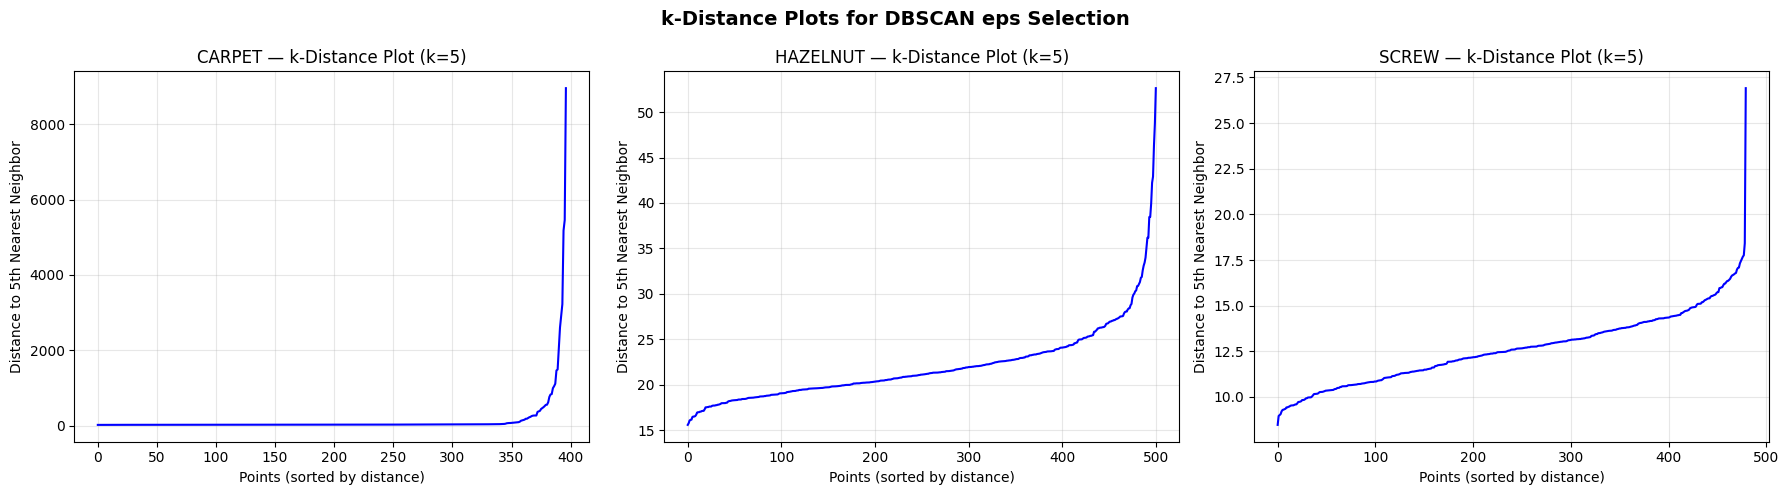

Look for the 'elbow' in each plot — the point where the
curve starts rising sharply. That y-value is a good eps.


In [24]:
# ============================================================
# Cell 22: DBSCAN Clustering Analysis (Professor's Suggestion)
# Purpose: Run DBSCAN on test set features to explore whether:
#   1. Anomalies get labeled as "noise" points (-1) by DBSCAN
#   2. Defective images cluster together by defect type
#
# Why DBSCAN?
#   - Unlike K-Means, DBSCAN doesn't need you to specify the 
#     number of clusters beforehand
#   - It can find clusters of arbitrary shape
#   - It labels points that don't belong to any cluster as 
#     "noise" (-1) — these could be our anomalies!
#
# Key hyperparameters:
#   - eps: maximum distance between two points to be neighbors
#   - min_samples: minimum points needed to form a cluster
#
# Strategy: We combine train (normal) + test (normal + anomaly)
#           features and run DBSCAN. Since the majority of data
#           is normal, DBSCAN should form clusters around normal
#           patterns. Anomalies might end up as noise or form
#           their own small clusters.
#
# We first need to find good eps values using k-distance plot.
# ============================================================

from sklearn.neighbors import NearestNeighbors

# k-distance plot helps us find a good eps value
# We look for the "elbow" — where distances start increasing sharply

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

k = 5  # Using min_samples=5, so we look at 5th nearest neighbor

for idx, category in enumerate(categories):
    # Combine train + test reduced features
    combined_features = np.vstack([
        data[category]["train_reduced"],
        data[category]["test_reduced"]
    ])
    
    # Compute distance to k-th nearest neighbor for each point
    nn = NearestNeighbors(n_neighbors=k)
    nn.fit(combined_features)
    distances, _ = nn.kneighbors(combined_features)
    
    # Sort distances to k-th neighbor (last column) in ascending order
    k_distances = np.sort(distances[:, -1])
    
    axes[idx].plot(range(len(k_distances)), k_distances, 'b-', linewidth=1.5)
    axes[idx].set_xlabel("Points (sorted by distance)")
    axes[idx].set_ylabel(f"Distance to {k}th Nearest Neighbor")
    axes[idx].set_title(f"{category.upper()} — k-Distance Plot (k={k})")
    axes[idx].grid(True, alpha=0.3)

plt.suptitle("k-Distance Plots for DBSCAN eps Selection", 
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Look for the 'elbow' in each plot — the point where the")
print("curve starts rising sharply. That y-value is a good eps.")

**What is this plot?**

For each data point, we calculated the distance to its 5th nearest neighbor. Then we sorted all these distances from smallest to largest and plotted them. Points that are in dense areas (surrounded by similar points) have small distances. Points that are isolated (far from others) have large distances.

**How to read the elbow:**

The curve is flat at the bottom where most points are close to their neighbors — these are the "normal" images that cluster together. Then it shoots up sharply — those are the outliers/anomalies that are far from everyone else. The **elbow** (where flat becomes steep) tells us the best `eps` value for DBSCAN.

**What we see:**

**Carpet** — flat around 50-100 for most points, then shoots up dramatically to 9000+ at the end. The elbow is around 340 - 400. The extreme spike means some carpet anomalies are VERY different from normal — consistent with GMM's huge scores on carpet.

**Hazelnut** — gradual increase from 15 to 25, then a sharp rise around point 450-500 going up to 55. The elbow is around 25-28. The rise is less extreme than carpet, meaning hazelnut anomalies are different but not as dramatically.

**Screw** — very gradual increase from 9 to about 15, then a gentle rise to 27 at the end. There's no sharp elbow — the curve rises smoothly. This confirms what we've seen all along — screw anomalies aren't clearly separated from normal points in feature space.


In [26]:
# ============================================================
# Cell 23: Run DBSCAN with selected eps values
# Purpose: Apply DBSCAN clustering on combined train+test data.
#          We analyze:
#          1. How many noise points (-1) are actual anomalies?
#          2. Do defect types form their own clusters?
#
# eps values chosen from k-distance plot elbows:
#   - Carpet: 250 (where the sharp rise begins)
#   - Hazelnut: 27 (where curve steepens)  
#   - Screw: 14 (gentle elbow region)
# ============================================================

from sklearn.cluster import DBSCAN

# eps values based on k-distance plot elbows
eps_values = {"carpet": 250, "hazelnut": 27, "screw": 14}

dbscan_results = {}

for category in categories:
    train_reduced = data[category]["train_reduced"]
    test_reduced = data[category]["test_reduced"]
    test_labels = data[category]["test_labels"]
    test_defect_types = data[category]["test_defect_types"]
    
    # Combine train + test
    combined = np.vstack([train_reduced, test_reduced])
    
    # Create labels for combined data
    # Train = all normal (0), Test = from test_labels
    combined_labels = np.concatenate([
        np.zeros(len(train_reduced)),   # Train: all normal
        test_labels                      # Test: 0=normal, 1=anomaly
    ])
    
    # Create defect type labels for combined data
    combined_defect_types = np.concatenate([
        np.array(["good"] * len(train_reduced)),  # Train: all good
        test_defect_types
    ])
    
    # Run DBSCAN
    eps = eps_values[category]
    dbscan = DBSCAN(eps=eps, min_samples=5)
    cluster_labels = dbscan.fit_predict(combined)
    
    # Separate results for test set only
    test_cluster_labels = cluster_labels[len(train_reduced):]
    
    dbscan_results[category] = {
        "cluster_labels": cluster_labels,
        "test_cluster_labels": test_cluster_labels
    }
    
    # Analysis
    n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
    n_noise = sum(cluster_labels == -1)
    
    # How many noise points are from test set and are actual anomalies?
    test_noise_mask = test_cluster_labels == -1
    noise_and_anomaly = sum(test_noise_mask & (test_labels == 1))
    noise_and_normal = sum(test_noise_mask & (test_labels == 0))
    
    print(f"{category.upper()} (eps={eps}, min_samples=5)")
    print(f"  Total clusters found: {n_clusters}")
    print(f"  Total noise points: {n_noise}")
    print(f"  ")
    print(f"  Test set noise analysis:")
    print(f"    Noise points that are ANOMALIES: {noise_and_anomaly} "
          f"out of {sum(test_labels==1)} total anomalies")
    print(f"    Noise points that are NORMAL:    {noise_and_normal} "
          f"out of {sum(test_labels==0)} total normals")
    print(f"  ")
    
    # Which clusters do different defect types end up in?
    print(f"  Defect type → cluster mapping (test set):")
    for defect in sorted(set(test_defect_types)):
        mask = test_defect_types == defect
        clusters_for_defect = test_cluster_labels[mask]
        unique, counts = np.unique(clusters_for_defect, return_counts=True)
        cluster_dist = ", ".join([f"Cluster {c}: {n}" for c, n in zip(unique, counts)])
        print(f"    {defect:25s} → {cluster_dist}")
    print()

CARPET (eps=250, min_samples=5)
  Total clusters found: 1
  Total noise points: 26
  
  Test set noise analysis:
    Noise points that are ANOMALIES: 26 out of 89 total anomalies
    Noise points that are NORMAL:    0 out of 28 total normals
  
  Defect type → cluster mapping (test set):
    color                     → Cluster -1: 3, Cluster 0: 16
    cut                       → Cluster -1: 10, Cluster 0: 7
    good                      → Cluster 0: 28
    hole                      → Cluster -1: 3, Cluster 0: 14
    metal_contamination       → Cluster 0: 17
    thread                    → Cluster -1: 10, Cluster 0: 9

HAZELNUT (eps=27, min_samples=5)
  Total clusters found: 1
  Total noise points: 26
  
  Test set noise analysis:
    Noise points that are ANOMALIES: 25 out of 70 total anomalies
    Noise points that are NORMAL:    0 out of 40 total normals
  
  Defect type → cluster mapping (test set):
    crack                     → Cluster -1: 12, Cluster 0: 6
    cut                

### DBSCAN Clustering Analysis — Key Findings

### What did we do?
We combined all training images (normal) with test images (normal + defective) 
and ran DBSCAN clustering. DBSCAN groups nearby points into clusters and labels 
isolated/distant points as "noise" (-1). The idea is: since our data is mostly 
normal images, DBSCAN should form clusters around the normal pattern. Anomalies 
that are very different from normal should end up as noise points.

### Finding 1: Zero normal images were labeled as noise
Across ALL three categories, DBSCAN labeled 0 normal test images as noise. 
This means every single normal image fit comfortably within a cluster. This 
confirms that normal images form tight, consistent groups in feature space — 
exactly what we'd expect from defect-free products.

### Finding 2: DBSCAN catches some anomalies as noise (Carpet & Hazelnut)
- **Carpet:** 26 out of 89 anomalies (29%) were flagged as noise. 
  Especially "cut" (10/17) and "thread" (10/19) defects — these are 
  visually dramatic changes that push images far from the normal cluster.
  "Metal contamination" (0/17 noise) blended into the normal cluster 
  entirely — this defect type is too subtle for DBSCAN to catch.

- **Hazelnut:** 25 out of 70 anomalies (36%) were flagged as noise.
  "Crack" defects were most detectable (12/18 = 67% flagged as noise)
  because cracks drastically change the hazelnut's appearance.
  "Cut" was hardest to detect (only 2/17 as noise).

### Finding 3: Screw forms many clusters — but defects DON'T cluster by type
- Screw produced 10 clusters instead of 1. This means even normal screw 
  images are spread across many sub-groups (different orientations, angles).
- Only 10 out of 119 anomalies (8%) were flagged as noise — very poor.
- Defect types (scratch_head, thread_side, etc.) are scattered across ALL 
  clusters with no pattern. For example, "scratch_head" images appear in 
  9 different clusters. This means screw defects are so subtle that they 
  look identical to normal screws even at the clustering level.

### Finding 4: Addressing the Professor's Question
The professor asked: "Do anomalies get captured as noise, or do defective 
images form their own clusters?"

**Answer:** It depends on the category.
- For **carpet and hazelnut**, a significant portion of anomalies ARE 
  captured as noise (29% and 36%), especially dramatic defect types like 
  cuts and cracks. However, many anomalies still blend into the normal 
  cluster — DBSCAN alone is not sufficient for anomaly detection.
- For **screw**, anomalies are NOT captured as noise effectively (only 8%). 
  Defective images do NOT form their own clusters either — they are 
  scattered randomly across normal clusters. This confirms that screw 
  defects are too subtle to separate in this feature space.

### Connection to Our Anomaly Detection Results
These DBSCAN findings align perfectly with our model results:
- Carpet & Hazelnut: High AUC-ROC (0.79-0.94) → defects are separable
- Screw: Low AUC-ROC (0.49-0.62) → defects blend with normal data

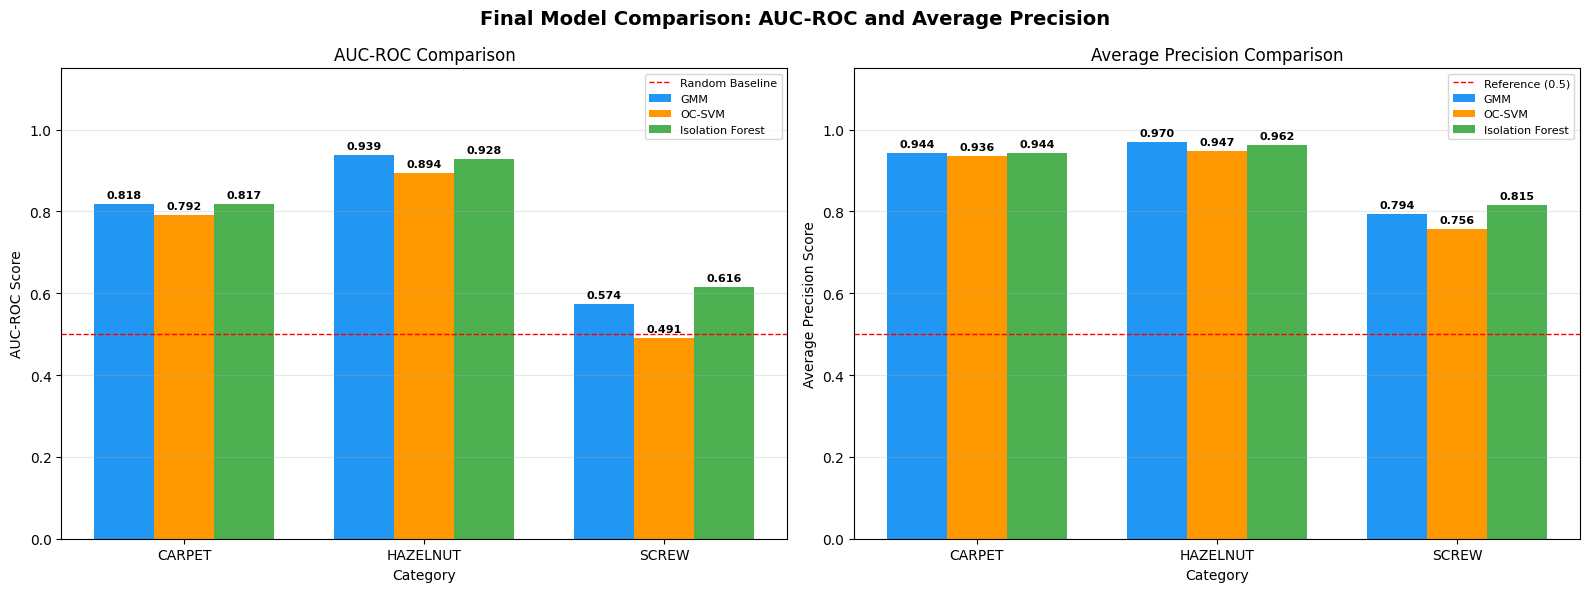


FINAL RESULTS SUMMARY

AUC-ROC Scores:
Category     GMM             OC-SVM          Iso Forest     
---------------------------------------------------------
CARPET       0.818           0.792           0.817          
HAZELNUT     0.939           0.894           0.928          
SCREW        0.574           0.491           0.616          
---------------------------------------------------------
AVERAGE      0.777           0.726           0.787          

Average Precision Scores:
Category     GMM             OC-SVM          Iso Forest     
---------------------------------------------------------
CARPET       0.944           0.936           0.944          
HAZELNUT     0.970           0.947           0.962          
SCREW        0.794           0.756           0.815          
---------------------------------------------------------
AVERAGE      0.902           0.880           0.907          

Best overall AUC-ROC:          Isolation Forest (0.787)
Best overall Avg Precision:    Iso

In [27]:
# ============================================================
# Cell 24: Comprehensive Model Comparison — Final Summary
# Purpose: Create a clean side-by-side comparison of all models
#          across both metrics (AUC-ROC and Average Precision)
#          for all 3 categories. This is the key results figure
#          for your presentation and report.
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models = ["GMM", "OC-SVM", "Isolation Forest"]
colors = ["#2196F3", "#FF9800", "#4CAF50"]  # Blue, Orange, Green
x = np.arange(len(categories))
width = 0.25

# --- Plot 1: AUC-ROC ---
for i, model in enumerate(models):
    values = [auc_scores[cat][model] for cat in categories]
    axes[0].bar(x + i * width, values, width, label=model, color=colors[i])
    # Add value labels on top of each bar
    for j, v in enumerate(values):
        axes[0].text(x[j] + i * width, v + 0.01, f'{v:.3f}', 
                      ha='center', va='bottom', fontsize=8, fontweight='bold')

axes[0].axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Random Baseline')
axes[0].set_xlabel("Category")
axes[0].set_ylabel("AUC-ROC Score")
axes[0].set_title("AUC-ROC Comparison")
axes[0].set_xticks(x + width)
axes[0].set_xticklabels([c.upper() for c in categories])
axes[0].legend(fontsize=8)
axes[0].set_ylim([0, 1.15])
axes[0].grid(True, alpha=0.3, axis='y')

# --- Plot 2: Average Precision ---
for i, model in enumerate(models):
    values = [ap_scores[cat][model] for cat in categories]
    axes[1].bar(x + i * width, values, width, label=model, color=colors[i])
    for j, v in enumerate(values):
        axes[1].text(x[j] + i * width, v + 0.01, f'{v:.3f}', 
                      ha='center', va='bottom', fontsize=8, fontweight='bold')

# Baseline for AP (proportion of anomalies)
axes[1].axhline(y=0.5, color='red', linestyle='--', linewidth=1, label='Reference (0.5)')
axes[1].set_xlabel("Category")
axes[1].set_ylabel("Average Precision Score")
axes[1].set_title("Average Precision Comparison")
axes[1].set_xticks(x + width)
axes[1].set_xticklabels([c.upper() for c in categories])
axes[1].legend(fontsize=8)
axes[1].set_ylim([0, 1.15])
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle("Final Model Comparison: AUC-ROC and Average Precision",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# --- Print final summary with averages ---
print("\n" + "=" * 65)
print("FINAL RESULTS SUMMARY")
print("=" * 65)

print("\nAUC-ROC Scores:")
print(f"{'Category':<12} {'GMM':<15} {'OC-SVM':<15} {'Iso Forest':<15}")
print("-" * 57)
for cat in categories:
    print(f"{cat.upper():<12} {auc_scores[cat]['GMM']:<15.3f} "
          f"{auc_scores[cat]['OC-SVM']:<15.3f} "
          f"{auc_scores[cat]['Isolation Forest']:<15.3f}")
gmm_avg_auc = np.mean([auc_scores[c]['GMM'] for c in categories])
ocsvm_avg_auc = np.mean([auc_scores[c]['OC-SVM'] for c in categories])
if_avg_auc = np.mean([auc_scores[c]['Isolation Forest'] for c in categories])
print("-" * 57)
print(f"{'AVERAGE':<12} {gmm_avg_auc:<15.3f} {ocsvm_avg_auc:<15.3f} {if_avg_auc:<15.3f}")

print("\nAverage Precision Scores:")
print(f"{'Category':<12} {'GMM':<15} {'OC-SVM':<15} {'Iso Forest':<15}")
print("-" * 57)
for cat in categories:
    print(f"{cat.upper():<12} {ap_scores[cat]['GMM']:<15.3f} "
          f"{ap_scores[cat]['OC-SVM']:<15.3f} "
          f"{ap_scores[cat]['Isolation Forest']:<15.3f}")
gmm_avg_ap = np.mean([ap_scores[c]['GMM'] for c in categories])
ocsvm_avg_ap = np.mean([ap_scores[c]['OC-SVM'] for c in categories])
if_avg_ap = np.mean([ap_scores[c]['Isolation Forest'] for c in categories])
print("-" * 57)
print(f"{'AVERAGE':<12} {gmm_avg_ap:<15.3f} {ocsvm_avg_ap:<15.3f} {if_avg_ap:<15.3f}")

print("\n" + "=" * 65)
# Determine overall winner
avg_aucs = {"GMM": gmm_avg_auc, "OC-SVM": ocsvm_avg_auc, "Isolation Forest": if_avg_auc}
avg_aps = {"GMM": gmm_avg_ap, "OC-SVM": ocsvm_avg_ap, "Isolation Forest": if_avg_ap}
best_auc = max(avg_aucs, key=avg_aucs.get)
best_ap = max(avg_aps, key=avg_aps.get)
print(f"Best overall AUC-ROC:          {best_auc} ({avg_aucs[best_auc]:.3f})")
print(f"Best overall Avg Precision:    {best_ap} ({avg_aps[best_ap]:.3f})")
print("=" * 65)

## Final Results — Key Conclusions

### 1. Overall Winner: Isolation Forest
Isolation Forest achieves the highest average scores on BOTH metrics:
- Best AUC-ROC: 0.787
- Best Average Precision: 0.907
This **confirms our proposal's hypothesis** that Isolation Forest would be the 
most robust model across all categories because it doesn't rely on distributional 
assumptions.

### 2. GMM is a Close Second
GMM performs nearly as well as Isolation Forest overall (AUC-ROC: 0.777, AP: 0.902) 
and actually **wins on individual categories** — it has the highest AUC-ROC on both 
carpet (0.818) and hazelnut (0.939). This supports our hypothesis that GMM excels 
on complex multi-modal categories due to its distributional flexibility.

### 3. OC-SVM is the Weakest Overall
OC-SVM has the lowest average scores (AUC-ROC: 0.726, AP: 0.880). Most critically, 
it scores 0.491 AUC-ROC on screw — **below random guessing (0.5)**. The tight 
boundary approach struggles when normal and anomalous data overlap heavily in 
feature space.

### 4. Screw is the Hard Case for Everyone
All models struggle with screw (AUC-ROC: 0.491–0.616). This is because:
- Screw images are grayscale with subtle defects (tiny scratches, thread variations)
- These defects barely change the deep feature representations
- DBSCAN analysis confirmed: defective screws scatter across normal clusters

### 5. Carpet and Hazelnut are Reliably Detectable
Both categories achieve strong results across all models:
- Carpet: AUC-ROC 0.792–0.818, AP 0.936–0.944
- Hazelnut: AUC-ROC 0.894–0.939, AP 0.947–0.970
These categories have visually distinct defects that show up clearly in 
deep feature space.

### 6. DBSCAN Provided Valuable Insight (Professor's Suggestion)
- DBSCAN correctly labeled **0 normal images as noise** across all categories
- It captured 29% of carpet anomalies and 36% of hazelnut anomalies as noise
- For screw, only 8% of anomalies were noise, and defect types did NOT form 
  their own clusters — confirming the fundamental difficulty of screw detection